# Assignment 12 — The Transformer Architecture

### Due: Monday, April 21, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References

- Vaswani, A., et al. (2017). Attention is all you need. *NeurIPS 2017*. https://arxiv.org/abs/1706.03762
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *NAACL 2019*. https://arxiv.org/abs/1810.04805
- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. *5th Workshop on Energy Efficient Machine Learning and Cognitive Computing — NeurIPS 2019*. https://arxiv.org/abs/1910.01108
- Liu, Y., et al. (2019). RoBERTa: A robustly optimized BERT pretraining approach. https://arxiv.org/abs/1907.11692
- Tenney, I., Das, D., & Pavlick, E. (2019). BERT rediscovers the classical NLP pipeline. *ACL 2019*.
- Hinton, G., Vinyals, O., & Dean, J. (2015). Distilling the knowledge in a neural network. https://arxiv.org/abs/1503.02531
- Jay Alammar. (2018). *The Illustrated Transformer*. https://jalammar.github.io/illustrated-transformer/
- Jay Alammar. (2018). *The Illustrated BERT, ELMo, and co.* https://jalammar.github.io/illustrated-bert/
- Harvard NLP. *The Annotated Transformer*. https://nlp.seas.harvard.edu/annotated-transformer/
- d2l.ai — Transformer Architecture. https://d2l.ai/chapter_attention-mechanisms-and-transformers/transformer.html
- d2l.ai — Self-Attention and Positional Encoding. https://d2l.ai/chapter_attention-mechanisms-and-transformers/self-attention-and-positional-encoding.html
- Kazemnejad, A. *Transformer Architecture: The Positional Encoding*. https://kazemnejad.com/blog/transformer_architecture_positional_encoding/
- HuggingFace. *Masked Language Modeling Tutorial*. https://huggingface.co/docs/transformers/tasks/masked_language_modeling
- HuggingFace. *DistilBERT Model Card*. https://huggingface.co/distilbert-base-uncased


In [1]:
import sys
import os
import time
import math
from enum import Enum
from functools import partial

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [2]:
from IPython.display import HTML, display

# Define CSS styles in a string variable for reuse across cells
css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [ ]:
def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [4]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**

As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [5]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [6]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [7]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [9]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [10]:
if IN_COLAB:
    # Install uv for fast installs
    !pip install -qU uv
    # Install project in editable mode, respecting pyproject.toml constraints
    !uv pip install -e .
    # Avoid manual -U commands that conflict with pyproject.toml
    print("Environment initialized from pyproject.toml configuration.")
else:
    print("Running locally, assuming project dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 109.8 MB/s eta 0:00:0000:0100:01
Using Python 3.12.13 environment at: /usr
Resolved 220 packages in 1.24s                                       
Prepared 23 packages in 2.71s                                            
Uninstalled 5 packages in 414ms
Installed 23 packages in 74ms                               
 + asttokens==3.0.1
 + async-lru==2.3.0
 - decorator==4.4.2
 + decorator==5.2.1
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.12.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.14.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.1
 + jupyterlab==4.5.6
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.56.0
 + torchmetrics==1.9.0
 - traitlets==5.7.1
 + traitlets==5.14.3
 - transformers==5.0.0
 + transformer

In [11]:
# Testing... only uncomment to force a hard restart of the kernel in Colab
if IN_COLAB:
    # import os
    # # Send signal 9 (SIGKILL) to the current process ID to force a hard restart
    # os.kill(os.getpid(), 9)
    pass

In [12]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [13]:
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [14]:
import wandb

In [15]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [16]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

# Authenticate with Hugging Face

Assuming that you already created your Hugging Face account and set up your token (see hw08), authenticate with Hugging Face. If you are running on Colab, you were instructed to store your token in a secret. This section assumes you set that up.

In [ ]:
if IN_COLAB:
    from google.colab import userdata
    from huggingface_hub import login

    login(token="")

In [18]:
show_section()

# Background

## Overview

Last week you built the **attention engine** — self-attention with Q/K/V projections, multi-head parallelism, and masked mean pooling. Your `AttentionClassifier` is powerful, but it is only *one layer* of what made "Attention Is All You Need" (Vaswani et al., 2017) revolutionary. This week you assemble the full machine.

A single self-attention layer can route information between positions, but it lacks two critical capabilities: (1) **per-token nonlinear computation** (attention is a linear weighted sum) and (2) **training stability at depth** (stacking multiple attention layers without additional structure causes gradient pathologies). The transformer encoder block solves both by wrapping self-attention in three additional components:

| Component | What it does | What problem it solves |
|-----------|-------------|----------------------|
| **Feedforward sublayer (FFN)** | Two linear layers with a nonlinearity | Per-token nonlinear transformation |
| **Residual connections** | Add the sublayer input back to its output | Gradient highways through deep stacks |
| **Layer normalization** | Normalize each token's features independently | Training stability across depths |

Together with **positional encoding** (which you previewed in Week 11), these four components form one **transformer encoder block**. Stack $N$ identical copies, and you have the encoder half of the original Transformer — and the complete architecture behind **BERT**, the model that redefined NLP in 2018.

This week takes you from a single attention layer to a production-grade transformer encoder, then shows you what happens when someone pretrains that architecture on the entire internet and lets you fine-tune it for your task.

## 1. The Transformer Encoder Block

The original Transformer (Vaswani et al., 2017) encoder block has this structure:

```
Input
  │
  ├──────────────────────┐
  ▼                      │ (residual)
LayerNorm                │
  │                      │
Multi-Head Self-Attention│
  │                      │
  + ◄────────────────────┘
  │
  ├──────────────────────┐
  ▼                      │ (residual)
LayerNorm                │
  │                      │
Feedforward (FFN)        │
  │                      │
  + ◄────────────────────┘
  │
Output
```

The diagram above shows the **Pre-LN** variant (normalize *before* the sublayer), which is what modern transformers use and what PyTorch's `nn.TransformerEncoderLayer` implements by default when you set `norm_first=True`. The original paper used **Post-LN** (normalize *after* the residual addition), but Pre-LN is more stable for deep stacks and is the standard in practice.

**Key insight:** The input and output of each block have the **same shape** — `(batch, seq_len, d_model)`. This is what makes stacking possible: you can chain $N$ identical blocks without any shape adaptation.

## 2. The Feedforward Sublayer (FFN)

The feedforward sublayer applies two linear transformations with a nonlinearity in between, **independently to each token position**:

$$\text{FFN}(x) = W_2 \cdot \text{GELU}(W_1 x + b_1) + b_2$$

where $W_1 \in \mathbb{R}^{d_{ff} \times d}$, $W_2 \in \mathbb{R}^{d \times d_{ff}}$, and $d_{ff}$ is typically $4 \times d$ (the "expansion factor").

**Why GELU over ReLU?** The Gaussian Error Linear Unit (GELU) provides a smoother gradient landscape than ReLU. This matters because masked language modeling (the BERT pretraining objective) requires the model to make fine-grained predictions about masked tokens — smooth gradients help the optimization find better solutions. GELU is defined as $\text{GELU}(x) = x \cdot \Phi(x)$ where $\Phi$ is the standard Gaussian CDF.

**Intuition:** Self-attention does *routing* — it decides which tokens should talk to which other tokens and creates context-aware representations by mixing information across positions. The FFN does *computation* — it transforms each token's representation independently through a nonlinear function. These are complementary: attention aggregates context, FFN processes it. Without the FFN, the transformer would be a series of linear weighted averages — powerful for routing but limited in representational capacity.

**Parameter count:** For each FFN sublayer: $d \times d_{ff} + d_{ff}$ (first linear + bias) $+ d_{ff} \times d + d$ (second linear + bias) $= 2 \cdot d \cdot d_{ff} + d_{ff} + d$. At $d = 256$, $d_{ff} = 1024$: roughly $2 \times 256 \times 1024 \approx 524\text{K}$ parameters. This is often *more* than the self-attention sublayer ($4d^2 = 262\text{K}$ at $d=256$).

## 3. Residual Connections

You first encountered residual connections in Week 7 (ResNet). The principle is the same here:

$$x_{\text{out}} = x + \text{sublayer}(x)$$

The sublayer only needs to learn the *residual* — the delta between input and output. This creates **gradient highways**: during backpropagation, the gradient flows directly through the addition operation without any multiplicative attenuation from layer weights or activation functions.

**Why this matters for transformers:** The original Transformer paper used $N = 6$ encoder layers. BERT-base uses $N = 12$. BERT-large uses $N = 24$. Without residual connections, gradients would vanish or explode long before reaching the early layers. Residuals make depth "free" in the sense that adding more layers cannot *hurt* the baseline — the network can always learn to set the sublayer output to zero and pass the input through unchanged.

In the Pre-LN variant, the pattern is:
```python
x = x + sublayer(LayerNorm(x))
```

## 4. Layer Normalization

Layer normalization (Ba et al., 2016) normalizes across the **feature dimension** for each token independently:

$$\text{LN}(x) = \gamma \frac{x - \mu}{\sigma + \epsilon} + \beta$$

where $\mu$ and $\sigma$ are computed over the $d$-dimensional feature vector of a single token, and $\gamma$, $\beta$ are learned scale and shift parameters.

**Key difference from BatchNorm:** Batch normalization (Week 7) normalizes across the *batch* dimension — it computes statistics over all examples for each feature channel. Layer normalization normalizes across the *feature* dimension for each individual example. This means:

| Property | BatchNorm | LayerNorm |
|----------|-----------|-----------|
| Normalizes across | Batch dimension | Feature dimension |
| Depends on other examples | Yes | **No** |
| Behavior at inference | Uses running stats | Same as training |
| Works with variable batch size | Poorly | Yes |
| Works with variable sequence length | N/A | Yes |

LayerNorm is preferred in transformers because (1) each token is normalized independently of others in the batch, (2) there is no dependence on batch statistics, so training and inference behave identically, and (3) it handles variable-length sequences naturally.

**Parameters per LayerNorm:** $2d$ (one $\gamma$ and one $\beta$ per feature). Negligible compared to attention and FFN.

## 5. Positional Encoding

You previewed positional encoding in Week 11. Since self-attention is permutation-invariant (shuffling the input tokens produces shuffled but otherwise identical outputs), position information must be injected explicitly. The sinusoidal positional encoding adds a position-dependent signal to each token embedding *before* the first encoder layer:

$$\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad \text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

This produces a unique pattern for each position, and the sinusoidal structure allows the model to learn relative position relationships because $\text{PE}(pos + k)$ can be expressed as a linear function of $\text{PE}(pos)$ for any fixed offset $k$.

**Sinusoidal vs. learned positional embeddings:** The original Transformer used sinusoidal PE, while BERT uses **learned** positional embeddings (`nn.Embedding(max_seq_len, d_model)` trained end-to-end). Sinusoidal PE can generalize to sequence lengths not seen during training; learned PE is more flexible but capped at the training length. In practice, both work well for sequences within the trained range.

**Implementation note:** In our `TransformerClassifier`, positional encoding is applied as:
```python
x = self.pos_encoder(self.embedding(tokens) * math.sqrt(d_model))
```
The `sqrt(d_model)` scaling prevents the embeddings from being overwhelmed by the PE signal — the embedding vectors have variance roughly $1/d$, so scaling by $\sqrt{d}$ brings them to unit variance to match the PE magnitude.

## 6. Stacking Encoder Layers

A transformer encoder is simply $N$ identical encoder blocks stacked sequentially. PyTorch provides this as:

```python
encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=N)
```

**How depth affects representations:** Research in "BERTology" (Tenney et al., 2019 — "BERT Rediscovers the Classical NLP Pipeline") shows that different layers capture different linguistic phenomena:
- **Early layers** (1–4): Surface-level features — POS tags, morphology, local syntax
- **Middle layers** (5–8): Syntactic structure — dependency parsing, constituency
- **Late layers** (9–12): Semantic relationships — coreference, sentiment, topic

**Depth vs. width trade-off:** Going deeper (more layers) is generally more effective than going wider (larger $d$) for the same parameter budget. BERT-base ($N=12$, $d=768$) outperforms a hypothetical wider-but-shallower model with the same parameter count. However, there are diminishing returns — especially on smaller datasets, where deep models overfit before the later layers learn anything useful.

**Typical configurations:**
- Original Transformer: $N = 6$
- BERT-base: $N = 12$, $d = 768$, $h = 12$ → 110M parameters
- BERT-large: $N = 24$, $d = 1024$, $h = 16$ → 340M parameters
- DistilBERT: $N = 6$, $d = 768$, $h = 12$ → 66M parameters (half the layers of BERT-base)

## 7. BERT: Architecture and Pretraining

**BERT** (Bidirectional Encoder Representations from Transformers; Devlin et al., 2019) is exactly a stack of $N$ transformer encoder blocks. What made it revolutionary was not the architecture itself — it is the standard encoder from "Attention Is All You Need" — but the **pretraining strategy**.

### Masked Language Modeling (MLM)

BERT is pretrained on a self-supervised objective called Masked Language Modeling:
1. Randomly select 15% of tokens in the input
2. Of those selected tokens:
   - 80% are replaced with a special `[MASK]` token
   - 10% are replaced with a random word from the vocabulary
   - 10% are left unchanged
3. The model must predict the original token at each masked position

This is **self-supervised** — no human labels are needed. The training signal comes from the text itself. This is why BERT could be pretrained on BookCorpus + English Wikipedia (~16 GB of text) — there are no annotation costs.

**Why MLM produces powerful representations:** To predict a masked word, the model must understand the surrounding context *bidirectionally*. Consider: "The [MASK] chased the mouse." The model must understand syntax (subject position), semantics (what chases mice?), and world knowledge to predict "cat." This forces every layer to build rich, contextual representations of every token.

**Next Sentence Prediction (NSP):** BERT also trained on NSP — given two sentences, predict whether the second follows the first. Later work (RoBERTa; Liu et al., 2019) showed that MLM alone is sufficient, and NSP can actually *hurt* performance. DistilBERT and most modern models drop NSP.

### Special Tokens

BERT introduces three special tokens:
- `[CLS]` — prepended to every input. The final-layer representation of `[CLS]` is used as the "sentence embedding" for classification tasks. During pretraining, `[CLS]` learns to aggregate information from the entire sequence.
- `[SEP]` — separates sentence pairs (for NSP and similar tasks).
- `[PAD]` — padding token, analogous to the `<PAD>` token you've used all semester.

### DistilBERT and Knowledge Distillation

**DistilBERT** (Sanh et al., 2019) uses **knowledge distillation** (Hinton et al., 2015) to compress BERT-base into a smaller model:
- 6 layers instead of 12 (every other layer removed)
- Same $d = 768$ and $h = 12$
- 66M parameters (40% fewer than BERT-base's 110M)
- Retains **97%** of BERT's performance on downstream tasks
- 60% faster inference

Knowledge distillation trains a **student** model (DistilBERT) to mimic a **teacher** model (BERT-base) by matching the teacher's output probability distributions (soft labels). Soft labels carry more information than hard labels — they encode the teacher's uncertainty (e.g., "this token is probably 'cat' but could be 'dog'"), which helps the student generalize better than training on one-hot hard labels alone.

### Fine-Tuning

The power of pretrained models comes from **fine-tuning**: take the pretrained BERT backbone (which has already learned universal language representations from billions of words), attach a small task-specific classification head, and train for a few epochs on your labeled dataset. This works because:
1. The pretrained backbone already understands grammar, semantics, and world knowledge
2. Fine-tuning only needs to adapt the representations to your specific task
3. Even with small datasets (thousands of examples), fine-tuning outperforms training from scratch

Analogy: this is the NLP equivalent of ImageNet pretraining + fine-tuning that you learned in Week 7 (transfer learning for CNNs).

In [19]:
show_todo("Background Check")

### Background Check

**Q1:** Given a `TransformerEncoderLayer` with $d = 256$, $d_{ff} = 1024$, $h = 4$ heads, compute the total parameter count. Break it down by component: (a) self-attention (Q/K/V projections + output projection), (b) feedforward sublayer, (c) layer normalization. Ignore bias terms for simplicity.

*Hint: Self-attention has four weight matrices ($W^Q$, $W^K$, $W^V$, $W^O$), each of size $d \times d$. The FFN has two weight matrices of sizes $d \times d_{ff}$ and $d_{ff} \times d$.*

**Answer:**

(a) The self-attention layer will have 4 * 256 * 256 = 262,144 parameters.


(b) The FFN has 2 * 256 * 1024 = 524,032 parameters.


(c) The layer norm has 2 * 256 = 512 parameters.


**Total:** 786,688 parameters




In [ ]:
show_todo("Background Check")

### Background Check

**Q2:** Explain why BERT's `[CLS]` token representation is used for classification rather than, say, the mean of all token representations. What does `[CLS]` learn to encode during pretraining, and why is it well-suited for downstream classification tasks?

**Answer:**
<br>
The `[CLS]` learns to code information from the whole sequence. It has no semantic meaning, but uses its attention heads to gather task-relevant information from all other tokens. Mean pooling could dilute important tokens since it treats all tokens equally. The NSP pretraining uses the `[CLS]` token output to predict whether two sentences are consecutive, so it captures the global, sentence-level summary. This makes it suitable for classification.
<br>

In [21]:
show_todo("Background Check")

### Background Check

**Q3:** A classmate says "DistilBERT is just a smaller BERT — they removed half the layers." Correct this explanation: what does knowledge distillation add beyond simply reducing the layer count? Why would a distilled 6-layer model outperform a randomly initialized 6-layer model trained on the same data with the same number of epochs?

**Answer:**
<br>
Knowledge distillation is not just about reducing layer count. It takes a SOTA model and captures the probabilities of its output logits (soft output distribution), which are used to train a smaller model to mimic the behavior and uncertainties of the larger model. These soft targets encode the teacher's learned similarities between classes, providing a richer training signal. It performs better than a randomly initialized 6-layer model because it receives denser supervision.
<br>

In [22]:
show_section()

# Lab

This week's lab takes you from a single attention layer (Week 11) to a full transformer encoder classifier, then compares it against a pretrained DistilBERT model to see the power of large-scale pretraining.

## Section 1: Engine Work — `TransformerClassifier` and `ModelConfig` Extension

Before we can train a transformer encoder classifier, we need to extend `my_engine` with several additions:

1. Add `num_encoder_layers` and `dim_feedforward` fields to `ModelConfig` in `config.py`
2. Implement `PositionalEncoding` module in `model.py`
3. Implement `TransformerClassifier` in `model.py`
4. Add a `"text_transformer"` dispatch case to `build_model()` in `utils.py`
5. Add `"text_transformer"` support to `sweep.py`


### Step 1.1: Extend `ModelConfig` with transformer fields

Open `src/my_engine/config.py` and add the following fields to the `ModelConfig` dataclass, after the existing attention fields:

```python
# --- Transformer encoder fields ---
num_encoder_layers: int = 2      # Number of stacked TransformerEncoderLayers
dim_feedforward: int = 512       # Hidden dimension in the FFN sublayer (typically 4 * embedding_dim)
```

Also update the `ModelConfig` docstring to document the new `"text_transformer"` model type and these two fields. For example, add:
```
--- Transformer encoder fields ---
num_encoder_layers: Number of stacked encoder layers (used by text_transformer).
dim_feedforward: FFN hidden dimension (used by text_transformer). Typically 4 * embedding_dim.
```

In [23]:
show_note("After adding the transformer fields to ModelConfig in config.py, restart your kernel and re-run the import cells above.")

### Step 1.2: Implement `PositionalEncoding` in `model.py`


While PyTorch does provide a standard `nn.TransformerEncoder` and `nn.TransformerEncoderLayer` (which we will use in the next step), it does not have an official **`nn.PositionalEncoding`** (sinusoidal) module. So: **positional encoding is something you compose**, not a single built-in “PE layer” in core PyTorch. Libraries like **Hugging Face Transformers** implement it inside each model class.

Open `src/my_engine/model.py` and add the `PositionalEncoding` class. This module adds sinusoidal position signals to the embedded input before it enters the transformer encoder stack.

Add this class *before* the `TransformerClassifier` class (which we implement in the next step).



```python
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for transformer models.

    Adds position-dependent sinusoidal signals to the input embeddings so that
    the transformer can distinguish token positions despite self-attention being
    permutation-invariant. Uses the formulation from Vaswani et al. (2017):
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    The PE matrix is precomputed for positions 0..max_len-1 and registered as a
    buffer (not a parameter) so it moves with the model to GPU but is not updated
    by the optimizer.

    Args:
        d_model (int): Embedding / model dimension.
        max_len (int): Maximum sequence length to precompute encodings for.
        dropout (float): Dropout probability applied after adding PE.
    """

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # ── Precompute the sinusoidal PE matrix ──
        pe = torch.zeros(max_len, d_model)              # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)

        # TODO: Compute the division term: 10000^(2i/d_model) via log-space for numerical stability
        div_term = ???            # (d_model/2,)

        # TODO: Even indices: sin; odd indices: cos; (1, max_len, d_model) for broadcasting
        pe[:, 0::2] = ???                       # even indices: sin
        pe[:, 1::2] = ???                       # odd indices: cos
        pe = pe.unsqueeze(0)                    # (1, max_len, d_model) for broadcasting

        # Register as buffer — moves with .to(device) but is not a trainable parameter
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add positional encoding to the input embeddings.

        Args:
            x: Tensor of shape (batch, seq_len, d_model).

        Returns:
            Tensor of same shape with positional encoding added and dropout applied.
        """
        x = x + self.pe[:, :x.size(1), :]               # slice PE to match actual seq_len
        return self.dropout(x)
```

**Key implementation details:**
- The `div_term` computation uses log-space arithmetic (`exp(... * -log(10000))`) instead of directly computing `10000 ** (2i/d)` — this avoids floating-point overflow for large dimensions.
- `register_buffer` ensures the PE matrix is saved in checkpoints and moves to GPU with the model, but the optimizer does not try to update it.
- The PE is precomputed for `max_len=5000` positions — far more than we need for AG News (~128 tokens), but cheap to store and ensures we never run out.

### What is `nn.TransformerEncoderLayer`?

`nn.TransformerEncoderLayer` is a **single Transformer encoder block** in one `nn.Module`: it combines **multi-head self-attention**, a **position-wise feed-forward network (FFN)**, **residual (skip) connections**, and **layer normalization**.

**Input / output:** A tensor of shape `(batch, sequence_length, d_model)` if `batch_first=True`. **Output has the same shape** — the block only refines token representations; it does not classify or reduce the sequence.

**What it does (one block):**  
Two sublayers, each with a residual path:

1. **Self-attention** — every token attends to every token (with optional padding mask).  
2. **FFN** — the same two-layer MLP applied **independently at each position** (shared weights), usually with `dim_feedforward ≈ 4 × d_model`.

**Layer norm order:** Use `norm_first=True` for **Pre-LN** (norm *before* each sublayer, then sublayer, then add the skip):  
`h = x + MHA(LN(x))`, then `h' = h + FFN(LN(h))`.  
`norm_first=False` matches the **original paper’s Post-LN** (“Add & Norm”).

**What it does *not* do:** It does **not** add **positional encoding**; you add `Embedding + PE` (or learned positions) **before** stacking layers. It also does **not** pool or produce class logits — you add pooling + a head for classification.

**Typical use:** Build one layer, then wrap several in `nn.TransformerEncoder(..., num_layers=N)` to stack **N** identical blocks.

### What is `nn.TransformerEncoder`?

`nn.TransformerEncoder` is a **stack of identical** `nn.TransformerEncoderLayer` blocks wrapped in one module. You pass in a **factory** for one layer (or the shared config PyTorch uses internally) and **`num_layers` = N**; the forward pass applies **layer 1 → layer 2 → … → layer N** in order.

**Input / output:** Same as one layer: typically `(batch, sequence_length, d_model)` when `batch_first=True`. **Shape is unchanged** from input to output — it only runs the sequence through **N** encoder blocks so representations get progressively richer.

**What it does:** Each block does **self-attention + FFN + residuals + layer norms** (exactly as in `TransformerEncoderLayer`). The **depth** of the encoder is **N**; more layers mean more rounds of “mix across positions” (attention) and “process each token” (FFN).

**What it does *not* do:** It still does **not** add **positional encoding** — you combine token embeddings with PE (or learned positions) **before** calling `TransformerEncoder`. It does **not** apply a **causal mask** unless you use the API for it; for **encoder-only** models you usually pass **`src_key_padding_mask`** so padded positions are ignored, not a causal “can’t see future” mask (that’s for decoders / GPT-style models).

**Typical pattern:** `embedding + positional encoding → TransformerEncoder → pool (e.g. mean over non-padding) → classifier head`.  

**Contrast:** One **`TransformerEncoderLayer`** = one block. **`TransformerEncoder`** = **repeat that block N times** with shared hyperparameters (`d_model`, `nhead`, `dim_feedforward`, `dropout`, `norm_first`, etc.).

### Step 1.3: Implement `TransformerClassifier` in `model.py`

Thankfully, PyTorch gives us a couple of very useful modules to ease the burden of implemnting a full TransformerEncoder!

Add the `TransformerClassifier` class to `model.py` after `PositionalEncoding`. This class follows the same pattern as `AttentionClassifier`: embedding → positional encoding → encoder stack → masked mean pooling → FC classifier head.

```python
class TransformerClassifier(nn.Module):
    """Transformer encoder text classifier using PyTorch's built-in modules.

    Architecture:
        Token IDs -> Embedding (* sqrt(d_model)) -> PositionalEncoding ->
        TransformerEncoder (N layers) -> Masked Mean Pool -> Classifier Head

    Each TransformerEncoderLayer contains self-attention + FFN + residual + LayerNorm.
    The model uses Pre-LN ordering (norm_first=True) for training stability.

    Args:
        num_outputs (int): Number of output classes.
        config (ModelConfig): Configuration containing:
            model_type (str): Must be "text_transformer".
            vocab_size (int): Vocabulary size for the embedding layer.
            embedding_dim (int): Model dimension (d_model). Must be divisible by num_heads.
            padding_idx (int): Token index treated as padding.
            freeze_embeddings (bool): If True, embedding weights are frozen.
            num_heads (int): Number of attention heads per encoder layer.
            num_encoder_layers (int): Number of stacked encoder layers (N).
            dim_feedforward (int): Hidden dimension of the FFN sublayer.
            dropout (list[float]): Dropout rates for the classifier head.
            hidden_units (list[int]): Hidden layer sizes for the classifier head.
    """

    def __init__(self, num_outputs: int, config: ModelConfig):
        super().__init__()

        if config.model_type != "text_transformer":
            raise ValueError(
                f"Invalid model_type: {config.model_type}. Expected 'text_transformer'."
            )

        # Confirm compatability of embedding dimension and number of heads
        if config.embedding_dim % config.num_heads != 0:
            raise ValueError(
                f"embedding_dim ({config.embedding_dim}) must be divisible by "
                f"num_heads ({config.num_heads})."
            )

        self.num_outputs = num_outputs
        self.config = config
        self.d_model = config.embedding_dim

        # TODO: ── Embedding layer ──
        self.embedding = ??? # and don't forget the freeze_embeddings option

        # TODO: ── Positional encoding ──
        self.pos_encoder = ????

        # TODO: ── Transformer encoder stack ──
        encoder_layer = nn.TransformerEncoderLayer(
            ???
        )

        # TODO: -- TransformerEncoder --
        self.transformer_encoder = nn.TransformerEncoder(
            ???
        )

        # TODO: ── Classifier head ──
        self.classifier_head = ???

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: LongTensor of token IDs, shape (batch, seq_len).

        Returns:
            Logit tensor of shape (batch, num_outputs).
        """
        # ── Build padding mask ──
        # PyTorch convention: True = ignore this position
        padding_mask = (x == self.config.padding_idx)   # (batch, seq_len)

        # TODO: ── Embed + scale + positional encoding ──
        embedded = ???

        # TODO: ── Transformer encoder ──
        # src_key_padding_mask has identical semantics to key_padding_mask from Week 11
        encoder_out = self.transformer_encoder(???)

        # ── Masked mean pooling ──
        encoder_out = encoder_out.masked_fill(
            padding_mask.unsqueeze(-1), 0.0
        )
        lengths = (~padding_mask).sum(dim=1, keepdim=True).float().clamp(min=1)
        pooled = encoder_out.sum(dim=1) / lengths        # (batch, d_model)

        # TODO: ── Classifier head ──
        return ???

    def num_parameters(self) -> tuple:
        """Return (total_params, trainable_params)."""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

    def get_architecture_config(self) -> dict:
        """Return a JSON-serializable description of the architecture."""
        from dataclasses import asdict
        return {
            "model_class": "TransformerClassifier",
            "num_outputs": self.num_outputs,
            "config": asdict(self.config),
        }

    def __str__(self) -> str:
        frozen = "frozen" if self.config.freeze_embeddings else "trainable"
        return (
            f"TransformerClassifier(vocab={self.config.vocab_size}, "
            f"d_model={self.config.embedding_dim} ({frozen}), "
            f"heads={self.config.num_heads}, layers={self.config.num_encoder_layers}, "
            f"d_ff={self.config.dim_feedforward}, out={self.num_outputs})"
        )

    def __repr__(self) -> str:
        return self.__str__()
```

**Don't forget** to add `import math` at the top of `model.py` if it isn't already there.

### Step 1.4: Add support in `utils.py`

Open `src/my_engine/utils.py`. Two changes are needed:

**1. Import the new class** — add `TransformerClassifier` to the import line:
```python
from src.my_engine.model import MLP_Model, CNN_Model, BagOfEmbeddings, TextCNN1D, RNNModel, TextRNNModel, AttentionClassifier, TransformerClassifier
```

**2. Add the dispatch case** in `build_model()` — add this `elif` before the final `else`:
```python
elif config.model_type == "text_transformer":
    return TransformerClassifier(num_outputs=num_outputs, config=config)
```

**3. Update `load_model_from_checkpoint()`** — add `"TransformerClassifier": "text_transformer"` to `dict_class_to_type`, and add a new branch:
```python
elif model_type == "text_transformer":
    model = TransformerClassifier(
        num_outputs=arch["num_outputs"],
        config=config,
    )
```

### Step 1.5: Add W&B Sweep Support in `sweep.py`

Open `src/my_engine/sweep.py`. Three changes are needed:

**1. Read the new config fields from wandb.config** — after the `num_heads` line, add:
```python
# TransformerClassifier
num_encoder_layers = getattr(config, "num_encoder_layers", default_model_config.num_encoder_layers)
dim_feedforward = getattr(config, "dim_feedforward", default_model_config.dim_feedforward)
```

**2. Add run naming** — add this block to the run-naming section:
```python
elif model_type == "text_transformer":
    run.name = (
        f"{model_type}_bs{trainer_batch_size}_lr{learning_rate:.5f}"
        f"_ed{embedding_dim}_nh{num_heads}_nl{num_encoder_layers}"
        f"_dff{dim_feedforward}_wd{weight_decay:.5f}"
    )
```

**3. Add to the text collate model list** — update the `if model_type in (...)` line:
```python
if model_type in ("bow", "textcnn", "text_rnn", "text_attn", "text_transformer"):
```

**4. Pass the new fields to ModelConfig** — add to the `ModelConfig(...)` constructor:
```python
# --- TransformerClassifier support ---
num_encoder_layers=num_encoder_layers,
dim_feedforward=dim_feedforward,
```

In [24]:
show_note("After making all engine edits (config.py, model.py, utils.py, sweep.py), restart your kernel and re-run all import cells.")

### Step 1.6: Verify the Engine Changes

Let's confirm that `TransformerClassifier` can be built through the standard `build_model()` factory and produces correct output shapes.

In [25]:
show_todo("Verify TransformerClassifier builds correctly through build_model() (Step 1.6)")

In [26]:
# ANSWER
from lantern.config import ModelConfig, TrainerConfig, MetricsConfig
from lantern.utils import build_model
from lantern.data import get_dataloaders, get_hf_text_dataset
from lantern.text import text_collate_fn, build_vocab, build_glove_embedding_matrix
from lantern.trainer import Trainer
from lantern.sweep import make_train_sweep
from lantern.config import ModelType

In [27]:
# ANSWER
# Create a ModelConfig with model_type="text_transformer" and verify build_model works.
#   Use vocab_size=20000, embedding_dim=128, num_heads=4, num_encoder_layers=2,
#   dim_feedforward=512, padding_idx=0, hidden_units=[64], dropout=[0.2]


test_config = ModelConfig(
    model_type=ModelType.TEXTTRANSFORMER,
    vocab_size=20000,
    embedding_dim=128,       # d_model — must be divisible by num_heads
    padding_idx=0,
    freeze_embeddings=False,
    num_heads=4,             # 128 / 4 = 32 dims per head
    num_encoder_layers=2,    # stack 2 transformer encoder blocks
    dim_feedforward=512,     # FFN hidden dim (4x d_model)
    hidden_units=[64],
    dropout=[0.2],
    max_seq_len=25,
)

# build_model dispatches to TransformerClassifier for model_type="text_transformer"
test_model = build_model(input_spec=0, num_outputs=4, config=test_config)
print(test_model)
total, trainable = test_model.num_parameters()
print(f"\nParameters: total={total:,}, trainable={trainable:,}")

TransformerClassifier(vocab=20000, d_model=128 (trainable), heads=4, layers=2, d_ff=512, out=4)

Parameters: total=2,965,316, trainable=2,965,316


/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/model.py:1452: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


In [28]:
# ANSWER
# Run a forward pass with dummy data to verify shapes.
#   Create a batch of 4 sequences, each of length 25, with random token IDs.
#   Pad the first two sequences to simulate variable lengths.
#   Confirm the output shape is (4, 4) — 4 examples, 4 classes.
dummy_input = torch.randint(1, 20000, (4, 25))  # (batch=4, seq_len=25), avoid 0=pad
dummy_input[0, 18:] = 0  # pad the first sequence from position 18 onward
dummy_input[1, 12:] = 0  # pad the second sequence from position 12 onward

test_model.eval()
with torch.no_grad():
    output = test_model(dummy_input)

print(f"Input shape:  {dummy_input.shape}")    # (4, 25)
print(f"Output shape: {output.shape}")         # (4, 4)
assert output.shape == (4, 4), f"Expected (4, 4), got {output.shape}"
print("Forward pass verified!")

Input shape:  torch.Size([4, 25])
Output shape: torch.Size([4, 4])
Forward pass verified!


### Reflective Exercise 1.1

Compare `AttentionClassifier` (Week 11) vs. `TransformerClassifier` at identical settings: `embedding_dim=128`, `num_heads=4`. How many extra parameters does one encoder block add over a single attention layer? Identify which new components contribute those parameters.

**Answer:**

<br>
We can cancel out the embedding and classifier head since they are identical. We just need to compare the attention layer to the transformer encoder layer. The attentiona layer has about 128*128*4 + 128*4 = 66,048 parameters while the transformer encoder layer has 66,048 (MHA) + 512*128*2+512+128 (FFN) + 2*2*128 (LayerNorm) = 198,272, giving us 132,224 extra parameters in the TransformerClassifier (due to FFN and LayerNorm).
<br>

## Section 2: AG News Baseline — TransformerClassifier vs. AttentionClassifier

Now we apply both architectures to **AG News**, a 4-class topic classification dataset (World, Sports, Business, Sci/Tech) with approx. 120K training examples and 7.6K test examples. AG News headlines are short ( roughly 15–40 tokens), so this is a good test of whether the extra transformer machinery helps on shorter text compared to the IMDB reviews you used in Week 11.

In [29]:
show_todo("Load AG News and train baseline models (Section 2)")

### Step 2.1: Set Training Epochs

In [30]:
# ANSWER
# Set the number of epochs and samples based on RUN_TRAINING_MODE.
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_lab = 10
    ag_train_samples = None   # use full dataset
    ag_test_samples = None
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_lab = 5
    ag_train_samples = 30000
    ag_test_samples = 3000
else:
    num_epochs_lab = 0
    ag_train_samples = 100
    ag_test_samples = 100

print(f"Training mode: {RUN_TRAINING_MODE.value}, epochs: {num_epochs_lab}, AG News samples: {ag_train_samples}, {ag_test_samples}")

Training mode: FULL, epochs: 10, AG News samples: None, None


### Step 2.2: Load the AG News Dataset

In [31]:
# ANSWER
# Load AG News using get_hf_text_dataset.
#   AG News has 4 classes: World (0), Sports (1), Business (2), Sci/Tech (3).
#   Use max_vocab_size=20000, max_seq_len=128 (headlines are short).
import random
from datasets import load_dataset
from lantern.data import get_dataloaders, get_hf_text_dataset


ag_train_ds, ag_test_ds, ag_vocab = get_hf_text_dataset(
    "ag_news",
    max_vocab_size=20000,
    train_subset_fn=lambda ds: ds.select(range(ag_train_samples)) if ag_train_samples else None,
    test_subset_fn=lambda ds: ds.select(range(ag_test_samples)) if ag_test_samples else None,
)

ag_label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

print(f"AG News train: {len(ag_train_ds)} examples")
print(f"AG News test:  {len(ag_test_ds)} examples")
print(f"Vocabulary: {len(ag_vocab)} words")
print(f"Labels: {ag_label_names.values()}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

AG News train: 120000 examples
AG News test:  7600 examples
Vocabulary: 20002 words
Labels: dict_values(['World', 'Sports', 'Business', 'Sci/Tech'])


### Step 2.3: Set common configuration variables

In [32]:
# ANSWER
# Shared configuration for both models — ensures fair comparison
AG_VOCAB_SIZE = len(ag_vocab)
AG_EMBEDDING_DIM = 128
AG_NUM_HEADS = 4
AG_MAX_SEQ_LEN = 128
AG_NUM_CLASSES = 4
AG_HIDDEN_UNITS = [64]
AG_DROPOUT = [0.2]
AG_BATCH_SIZE = 64
AG_LR = 0.001

# Create collate function with truncation for memory safety
ag_collate_fn = partial(text_collate_fn, max_seq_len=AG_MAX_SEQ_LEN, padding_value=0)

### Step 2.4: Train AttentionClassifier (Week 11 baseline)

In [31]:
# ANSWER
# Create an AttentionClassifier config and train on AG News.
#   Use the shared hyperparameters defined above.
attn_config = ModelConfig(
    model_type=ModelType.TEXTATTN,
    hidden_units=AG_HIDDEN_UNITS,
    dropout=AG_DROPOUT,
    vocab_size=AG_VOCAB_SIZE,
    embedding_dim=AG_EMBEDDING_DIM,
    padding_idx=0,
    max_seq_len=AG_MAX_SEQ_LEN,
    num_heads=AG_NUM_HEADS,
    
)

attn_model = build_model(input_spec=0, num_outputs=AG_NUM_CLASSES, config=attn_config)
print(attn_model)
total_attn, trainable_attn = attn_model.num_parameters()
print(f"AttentionClassifier params: total={total_attn:,}, trainable={trainable_attn:,}")

AttentionClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
AttentionClassifier params: total=2,634,820, trainable=2,634,820


In [32]:
# ANSWER
# Train the AttentionClassifier using Trainer.
#   Log to W&B project "csci357-hw12-lab2".
attn_trainer_config = TrainerConfig(
    trainer_batch_size=AG_BATCH_SIZE,
    evaluator_batch_size=AG_BATCH_SIZE,
    learning_rate=AG_LR,
    num_epochs=num_epochs_lab,
)

attn_train_loader, attn_val_loader, _ = get_dataloaders(
    train_dataset=ag_train_ds, 
    eval_dataset=ag_test_ds,
    train_batch_size=AG_BATCH_SIZE,
    eval_batch_size=AG_BATCH_SIZE,
    collate_fn=ag_collate_fn,
)

attn_optimizer = optim.Adam(attn_model.parameters(), lr=AG_LR)
attn_criterion = nn.CrossEntropyLoss()

attn_run = None
if DO_WANDB_LOGGING and num_epochs_lab > 0:
    attn_run = wandb.init(
        project="csci357-hw12-lab2",
        name=f"{user_initials}_attn_ed{AG_EMBEDDING_DIM}_nh{AG_NUM_HEADS}",
        reinit=True,
    )

attn_trainer = Trainer(
    model=attn_model,
    optimizer=attn_optimizer,
    criterion=attn_criterion,
    config=attn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    run=attn_run,
)

attn_start = time.time()
attn_results = attn_trainer.fit(attn_train_loader, attn_val_loader)
attn_time = time.time() - attn_start

if attn_run:
    attn_trainer.finish_run()

print(f"AttentionClassifier training time: {attn_time:.1f}s")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cb073 (cb073-bucknell-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Accuracy=83.90%  Val Accuracy=88.70%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=91.20%  Val Accuracy=90.37%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=93.07%  Val Accuracy=90.83%
Epoch 3:
Train Accuracy=94.30%  Val Accuracy=90.76%
Epoch 4:
Train Accuracy=95.34%  Val Accuracy=91.00%
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=96.20%  Val Accuracy=90.54%
Epoch 6:
Train Accuracy=96.93%  Val Accuracy=90.47%


epoch,▁▂▃▅▆▇█
train_accuracy,▁▅▆▇▇██
val_accuracy,▁▆▇▇█▇▆
epoch,6
train_accuracy,0.96926
val_accuracy,0.90474


AttentionClassifier training time: 561.6s


### Step 2.5: Train TransformerClassifier

In [33]:
# ANSWER
# Create a TransformerClassifier config with 2 encoder layers
#   and train on AG News with the same hyperparameters.
trans_config = ModelConfig(
    model_type=ModelType.TEXTTRANSFORMER,
    vocab_size=AG_VOCAB_SIZE,
    embedding_dim=AG_EMBEDDING_DIM,
    num_heads=AG_NUM_HEADS,
    num_encoder_layers=2,
    dim_feedforward=512,
    max_seq_len=AG_MAX_SEQ_LEN,
    padding_idx=0,
    hidden_units=AG_HIDDEN_UNITS,
    dropout=AG_DROPOUT,
)

trans_model = build_model(input_spec=0, num_outputs=AG_NUM_CLASSES, config=trans_config)
print(trans_model)
total_trans, trainable_trans = trans_model.num_parameters()
print(f"TransformerClassifier params: total={total_trans:,}, trainable={trainable_trans:,}")

TransformerClassifier(vocab=20002, d_model=128 (trainable), heads=4, layers=2, d_ff=512, out=4)
TransformerClassifier params: total=2,965,572, trainable=2,965,572


/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/model.py:1451: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


In [34]:
# ANSWER
trans_trainer_config = TrainerConfig(
    trainer_batch_size=AG_BATCH_SIZE,
    evaluator_batch_size=AG_BATCH_SIZE,
    learning_rate=AG_LR,
    num_epochs=num_epochs_lab,
)

trans_train_loader, trans_val_loader, _ = get_dataloaders(
    train_dataset=ag_train_ds, 
    eval_dataset=ag_test_ds,
    train_batch_size=AG_BATCH_SIZE,
    eval_batch_size=AG_BATCH_SIZE,
    collate_fn=ag_collate_fn,
)

trans_optimizer = optim.Adam(trans_model.parameters(), lr=AG_LR)
trans_criterion = nn.CrossEntropyLoss()

trans_run = None
if DO_WANDB_LOGGING and num_epochs_lab > 0:
    trans_run = wandb.init(
        project="csci357-hw12-lab2",
        name=f"{user_initials}_transformer_ed{AG_EMBEDDING_DIM}_nh{AG_NUM_HEADS}_nl2_dff512",
        reinit=True,
    )

trans_trainer = Trainer(
    model=trans_model,
    optimizer=trans_optimizer,
    criterion=trans_criterion,
    config=trans_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    run=trans_run,
)

trans_start = time.time()
trans_results = trans_trainer.fit(trans_train_loader, trans_val_loader)
trans_time = time.time() - trans_start

if trans_run:
    trans_trainer.finish_run()

print(f"TransformerClassifier training time: {trans_time:.1f}s")

Epoch 0:
Train Accuracy=81.82%  Val Accuracy=89.51%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=90.11%  Val Accuracy=90.86%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=91.63%  Val Accuracy=91.20%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=92.59%  Val Accuracy=91.64%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=93.25%  Val Accuracy=91.97%
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=93.89%  Val Accuracy=92.20%
Epoch 6:
Train Accuracy=94.30%  Val Accuracy=91.82%
Epoch 7:
Train Accuracy=94.66%  Val Accuracy=91.76%
Epoch 8:
Train Accuracy=95.01%  Val Accuracy=91.95%


epoch,▁▂▃▄▅▅▆▇█
train_accuracy,▁▅▆▇▇▇███
val_accuracy,▁▄▅▇▇█▇▇▇
epoch,8
train_accuracy,0.95012
val_accuracy,0.91947


TransformerClassifier training time: 3580.2s


### Step 2.6: Side-by-Side Comparison

In [35]:
# ANSWER
# Build a comparison DataFrame with val accuracy, param count, and training time.
comparison_data = {
    "Model": ["AttentionClassifier", "TransformerClassifier (N=2)"],
    "Val Accuracy": [
        attn_results.get("val_accuracy", 0.0) if attn_results else 0.0,
        trans_results.get("val_accuracy", 0.0) if trans_results else 0.0,
    ],
    "Total Params": [f"{total_attn:,}", f"{total_trans:,}"],
    "Training Time (s)": [f"{attn_time:.1f}", f"{trans_time:.1f}"],
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                      Model  Val Accuracy Total Params Training Time (s)
        AttentionClassifier      0.904737    2,634,820             561.6
TransformerClassifier (N=2)      0.919474    2,965,572            3580.2


### Analysis 2.1

Do the extra FFN + LN parameters of the TransformerClassifier help on short AG News headlines compared to a single attention layer? Write 2–3 sentences interpreting your results.

**Answer:**

<br>
It seems to lead to higher accuracy with the TransformerClassifier. However, the training time was much longer even though the number of parameters did not differ too much.
<br>

## Section 3: Depth Sweep — How Many Encoder Layers?

Now we investigate how the number of stacked encoder layers ($N$) affects accuracy, overfitting, and training time on AG News.

### Reflective Exercise 3.1 (answer BEFORE running the experiments)

At 6 layers, the total attention + FFN parameters are 6× those of a 1-layer model. Does accuracy scale proportionally with depth? Why or why not?

**Answer:**

<br>
No, accuracy does not scale proportionally with depth. The layers returns are diminishing since earlier layers capture more fundamental features while later ones refine them (have less effect on accuracy). Optimization is also harder for deeper networks since the gradient path is now longer. Having more layers could also be conducive to overfitting of the model.
<br>

In [ ]:
show_todo("Run depth sweep over num_encoder_layers (Section 3)")

### Step 3.1: Configure and Run the Depth Sweep

> IMPORTANT: Run locally first with just one layer and a few epochs. When you confirm it's working, then rerun on Colab (or plan on waiting a while!)


In [39]:
# ANSWER
# Run a W&B sweep over num_encoder_layers ∈ {1, 2, 4, 6},
#   holding embedding_dim=128, num_heads=4, dim_feedforward=512 fixed.
#   Log to W&B project "csci357-hw12-lab3".
sweep_config = {
    "method": "grid",
    "parameters": {
        "model_type": {"value": "texttransformer"},
        "num_encoder_layers": {"values": [1, 2, 4, 6]},
        # Fixed hyperparameters
        "embedding_dim": {"value": AG_EMBEDDING_DIM},
        "num_heads": {"value": AG_NUM_HEADS},
        "dim_feedforward": {"value": 4 * AG_EMBEDDING_DIM},
        "vocab_size": {"value": AG_VOCAB_SIZE},
        "padding_idx": {"value": 0},
        "max_seq_len": {"value": AG_MAX_SEQ_LEN},
        "hidden_units": {"value": AG_HIDDEN_UNITS},
        "dropout": {"value": AG_DROPOUT},
        "trainer_batch_size": {"value": AG_BATCH_SIZE},
        "learning_rate": {"value": AG_LR},
        "num_epochs": {"value": num_epochs_lab},
    },
}

if DO_WANDB_LOGGING and num_epochs_lab > 0:
    train_sweep_fn = make_train_sweep(
        wandb_project_name="csci357-hw12-lab3",
        datasets=(ag_train_ds, ag_test_ds),
        device=accel_device,
        input_spec=0,
        num_outputs=AG_NUM_CLASSES,
        wandb_name_prefix=user_initials,
        text_collate_fn=text_collate_fn,
        metrics_config_param=MetricsConfig(task="multiclass", names=["accuracy"]),
    )

    # sweep_id = wandb.sweep(sweep_config, project="csci357-hw12-lab3", entity=entity)
    sweep_id = wandb.sweep(sweep_config, project="csci357-hw12-lab3")
    wandb.agent(sweep_id, function=train_sweep_fn, count=4)
    print(f"Depth sweep complete! Sweep ID: {sweep_id}")
else:
    print("Skipping depth sweep (training mode is NONE or W&B logging is off)")
    sweep_id = None

Create sweep with ID: 092y9ffw
Sweep URL: https://wandb.ai/cb073-bucknell-university/csci357-hw12-lab3/sweeps/092y9ffw


wandb: Agent Starting Run: t3d1ovrp with config:
wandb: 	dim_feedforward: 512
wandb: 	dropout: [0.2]
wandb: 	embedding_dim: 128
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.001
wandb: 	max_seq_len: 128
wandb: 	model_type: texttransformer
wandb: 	num_encoder_layers: 1
wandb: 	num_epochs: 10
wandb: 	num_heads: 4
wandb: 	padding_idx: 0
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 20002
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dim_feedforward': 512, 'dropout': [0.2], 'embedding_dim': 128, 'hidden_units': [64], 'learning_rate': 0.001, 'max_seq_len': 128, 'model_type': 'texttransformer', 'num_encoder_layers': 1, 'num_epochs': 10, 'num_heads': 4, 'padding_idx': 0, 'trainer_batch_size': 64, 'vocab_size': 20002}
Run name set to: CMB_texttransformer_bs64_lr0.00100_ed128_nh4_nl1_dff512_wd0.00000


/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/model.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  


Epoch 0:
Train Accuracy=81.69%  Val Accuracy=89.33%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 1:
Train Accuracy=90.08%  Val Accuracy=90.82%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 2:
Train Accuracy=91.85%  Val Accuracy=91.57%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 3:
Train Accuracy=92.67%  Val Accuracy=91.66%
Epoch 4:
Train Accuracy=93.46%  Val Accuracy=91.64%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
--> Saving checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 5:
Train Accuracy=93.98%  Val Accuracy=91.95%
Epoch 6:
Train Accuracy=94.38%  Val A

...

Run complete! val_accuracy: 91.96%


wandb: Agent Starting Run: oofqzg22 with config:
wandb: 	dim_feedforward: 512
wandb: 	dropout: [0.2]
wandb: 	embedding_dim: 128
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.001
wandb: 	max_seq_len: 128
wandb: 	model_type: texttransformer
wandb: 	num_encoder_layers: 6
wandb: 	num_epochs: 10
wandb: 	num_heads: 4
wandb: 	padding_idx: 0
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 20002
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dim_feedforward': 512, 'dropout': [0.2], 'embedding_dim': 128, 'hidden_units': [64], 'learning_rate': 0.001, 'max_seq_len': 128, 'model_type': 'texttransformer', 'num_encoder_layers': 6, 'num_epochs': 10, 'num_heads': 4, 'padding_idx': 0, 'trainer_batch_size': 64, 'vocab_size': 20002}
Run name set to: CMB_texttransformer_bs64_lr0.00100_ed128_nh4_nl6_dff512_wd0.00000
Epoch 0:
Train Accuracy=82.66%  Val Accuracy=89.64%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 1:
Train Accuracy=90.20%  Val Accuracy=90.17%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 2:
Train Accuracy=91.76%  Val Accuracy=91.47%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-lab3-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-lab3-last.pt
Epoch 3:
Train Acc

epoch,▁▂▃▄▅▆▇█
train_accuracy,▁▅▆▇▇███
val_accuracy,▁▂▆▇▇█▇█
epoch,7
train_accuracy,0.94587
val_accuracy,0.92171


Run complete! val_accuracy: 92.17%
Depth sweep complete! Sweep ID: 092y9ffw


### Step 3.2: Retrieve Sweep Results

Use the `wandb.Api()` call and retrieve the train and validation accuracy for each run, and retrieve the learning curve so you can plot it.

> NOTE: W&B API quirk — always retrieve `run.summary` before `run.config` on each run object. Accessing `config` first causes a serialization issue that silently corrupts the `summary` values.

This is the pattern you want:

```python
api = wandb.Api()
runs = api.runs(f"csci357-hw12-lab3", filters={"sweep": sweep_id})
# runs = api.runs(f"{entity}/csci357-hw12-lab3", filters={"sweep": sweep_id})
print(f"Retrieved {len(runs)} runs from sweep {sweep_id}")
print(f"Run summary: {runs[0].summary}")
print(f"Run config: {runs[0].config}")
```


Retrieved 4 runs from sweep 092y9ffw
 num_encoder_layers  val_accuracy                                                          run_name
                  1      0.918158 CMB_texttransformer_bs64_lr0.00100_ed128_nh4_nl1_dff512_wd0.00000
                  2      0.917500 CMB_texttransformer_bs64_lr0.00100_ed128_nh4_nl2_dff512_wd0.00000
                  4      0.919605 CMB_texttransformer_bs64_lr0.00100_ed128_nh4_nl4_dff512_wd0.00000
                  6      0.921710 CMB_texttransformer_bs64_lr0.00100_ed128_nh4_nl6_dff512_wd0.00000


/tmp/ipykernel_691/2387483366.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


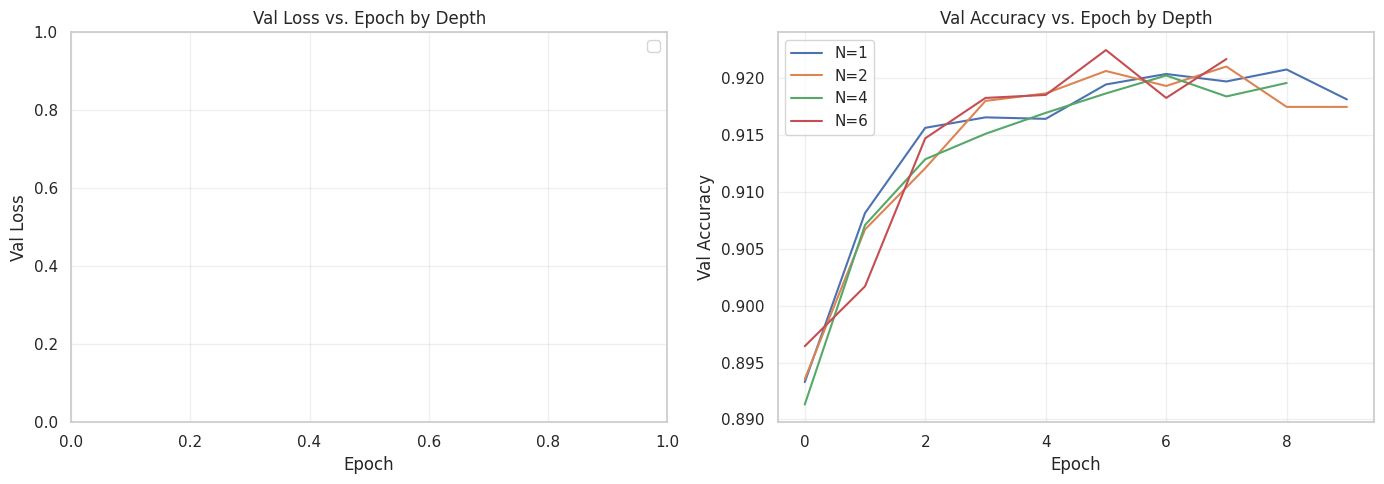

In [40]:
# ANSWER
# Use wandb.Api() to retrieve results from the depth sweep.
#   Build a DataFrame with num_encoder_layers, val accuracy, param count, and time per epoch.
if sweep_id and DO_WANDB_LOGGING:
    api = wandb.Api()
    runs = api.runs(f"csci357-hw12-lab3", filters={"sweep": sweep_id})
    # runs = api.runs(f"{entity}/csci357-hw12-lab3", filters={"sweep": sweep_id})
    print(f"Retrieved {len(runs)} runs from sweep {sweep_id}")

    depth_results = []
    depth_histories = {}  # Store the learning curves here

    for i in range(len(runs)):
        # RETRIEVE summary FIRST! WILL NOT WORK IF YOU RETRIEVE config FIRST!
        summary = runs[i].summary
        cfg = runs[i].config
        history = runs[i].history()

        num_encoder_layers_int = int(cfg.get("num_encoder_layers", 1))

        depth_results.append({
            "num_encoder_layers": num_encoder_layers_int,
            "val_accuracy": summary.get("val_accuracy", 0.0),
            "run_name": runs[i].name,
        })

        # Fetch the loss/accuracy curves for this specific run
        depth_histories[num_encoder_layers_int] = history

    depth_df = pd.DataFrame(depth_results).sort_values("num_encoder_layers")
    print(depth_df.to_string(index=False))

    # PLOT the learning curves
    if depth_histories:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                                                                                                                                  
        for n_layers, hist in sorted(depth_histories.items()):                                                                                                                                                                           
            if "val_loss" in hist.columns:
                axes[0].plot(hist["val_loss"].dropna().values, label=f"N={n_layers}")                                                                                                                                                    
            if "val_accuracy" in hist.columns:                                                                                                                                                                                           
                axes[1].plot(hist["val_accuracy"].dropna().values, label=f"N={n_layers}")                                                                                                                                                
        axes[0].set_title("Val Loss vs. Epoch by Depth")                                                                                                                                                                                 
        axes[0].set_xlabel("Epoch")                                                                                                                                                                                                      
        axes[0].set_ylabel("Val Loss")                                                                                                                                                                                                   
        axes[0].legend()                                                                                                                                                                                                                 
        axes[0].grid(True, alpha=0.3)                                                                                                                                                                                                    
        axes[1].set_title("Val Accuracy vs. Epoch by Depth")                                                                                                                                                                             
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Val Accuracy")                                                                                                                                                                                               
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)                                                                                                                                                                                                    
        plt.tight_layout()
        plt.show()

        
else:
    print("No sweep results to display (sweep not run)")
    depth_df = pd.DataFrame()
    depth_histories = {}

### Step 3.3: Visualize Depth vs. Accuracy

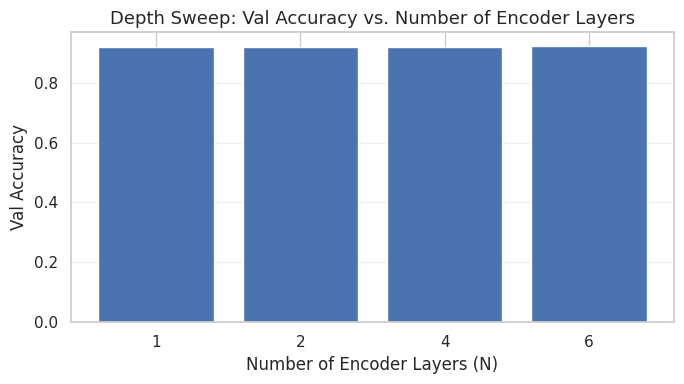

In [41]:
# ANSWER
# Plot val accuracy vs. N layers.
if not depth_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(depth_df["num_encoder_layers"].astype(str), depth_df["val_accuracy"])                                                                                                                                                         
    ax.set_xlabel("Number of Encoder Layers (N)", fontsize=12)                                                                                                                                                                           
    ax.set_ylabel("Val Accuracy", fontsize=12)                                                                                                                                                                                           
    ax.set_title("Depth Sweep: Val Accuracy vs. Number of Encoder Layers", fontsize=13)                                                                                                                                                  
    ax.grid(True, axis="y", alpha=0.3)                                                                                                                                                                                                   
    plt.tight_layout()
    plt.show()
    
else:
    print("No depth sweep data to plot")

In [ ]:
# Forcefully shut down the W&B backend and clear internal state.
# IMPORTANT: THis is necessary when going from a sweep to a single run or vice versa.
wandb.teardown()

### Analysis 3.1

Did accuracy scale proportionally with depth? Compare your prediction from Reflective Exercise 3.1 with the actual results. Which number of layers gives the best trade-off between accuracy and training time?

**Answer:**

<br>
No, accuracy was very similar for all depths. I was correct with my prediction in the Reflective Exercise 3.1. The depth of 1 had the best trade-off between accuracy and training time.
<br>

## Section 4: Masked Language Modeling (MLM) from Scratch

Now we implement the self-supervised learning objective that made BERT possible. Instead of training a model to predict topic labels (supervised), we train it to predict **masked words** from context (self-supervised). This is the same objective BERT was pretrained on — except BERT was trained on 16 GB of text and we'll use AG News.

This section has three parts:
1. Build a masking collate function that randomly masks 15% of tokens
2. Modify the model head to predict vocabulary tokens instead of classes
3. Train the MLM model and visualize predictions

This is the most conceptually novel section — it is the students' first self-supervised task. The masking collate function is partially scaffolded (structure provided, key logic left for students). Common mistakes: masking the PAD token, forgetting to create the labels tensor, computing loss on non-masked positions.

In [ ]:
show_warning("Section 4 introduces self-supervised learning. The key insight: the training signal comes from the text itself — no human labels needed. This is what makes pretraining on the entire internet possible.")

### Step 4.1: Masking Collate Function

We need a custom collate function that takes a batch of (token_ids, label) pairs, ignores the labels (this is self-supervised!), and randomly masks 15% of the non-padding tokens using the BERT strategy:
- 80% of selected positions → replaced with a `<MASK>` token ID
- 10% of selected positions → replaced with a random word ID
- 10% of selected positions → left unchanged (but still predicted)

In [42]:
# First, add a <MASK> token to the vocabulary if it doesn't exist.
MASK_TOKEN = "<MASK>"
if MASK_TOKEN not in ag_vocab:
    ag_vocab[MASK_TOKEN] = len(ag_vocab)
MASK_ID = ag_vocab[MASK_TOKEN]
PAD_ID = ag_vocab["<PAD>"]
MLM_VOCAB_SIZE = len(ag_vocab)

print(f"<MASK> token ID: {MASK_ID}")
print(f"Updated vocab size: {MLM_VOCAB_SIZE}")

<MASK> token ID: 20002
Updated vocab size: 20003


In [43]:
# Implement the MLM masking collate function.
#   This function takes a batch from the text dataset, masks 15% of non-padding tokens,
#   and returns (masked_input, mlm_labels) where mlm_labels is -100 at non-masked positions
#   (CrossEntropyLoss ignores -100 by default).
def mlm_collate_fn(batch, padding_value=0, max_seq_len=128, mask_prob=0.15,
                    mask_id=MASK_ID, vocab_size=MLM_VOCAB_SIZE):
    """Collate function for Masked Language Modeling.

    Pads sequences, then randomly masks 15% of non-padding tokens following the
    BERT masking strategy (80% [MASK], 10% random, 10% unchanged).

    Args:
        batch: List of (token_ids_tensor, label_tensor) tuples.
        padding_value: PAD token index.
        max_seq_len: Maximum sequence length (truncate longer sequences).
        mask_prob: Fraction of non-padding tokens to mask.
        mask_id: Token ID for the <MASK> token.
        vocab_size: Total vocabulary size (for random replacement).

    Returns:
        Tuple of (masked_input, mlm_labels) where:
            masked_input: (batch, seq_len) — input with masked tokens
            mlm_labels: (batch, seq_len) — original token IDs at masked positions,
                        -100 elsewhere (ignored by CrossEntropyLoss)
    """
    texts, _ = zip(*batch)  # ignore original task labels — MLM is self-supervised

    # Truncate sequences to max_seq_len
    if max_seq_len is not None:
        texts = tuple(t[:max_seq_len] for t in texts)

    # Pad to uniform length within the batch
    padded = pad_sequence(texts, batch_first=True, padding_value=padding_value)
    # (batch, seq_len)

    # ── Create masks ──
    # Only mask non-padding positions
    non_pad_mask = (padded != padding_value)  # True where there are real tokens

    # Randomly select mask_prob fraction of non-padding positions
    rand_matrix = torch.rand(padded.shape)    # uniform [0, 1)
    mask_positions = (rand_matrix < mask_prob) & non_pad_mask  # True = will be masked

    # ── Build MLM labels ──
    # -100 at positions we don't predict; original token ID at masked positions
    mlm_labels = torch.full(padded.shape, -100, dtype=torch.long)
    mlm_labels[mask_positions] = padded[mask_positions]  # ground truth at masked positions

    # ── Apply the BERT masking strategy to the input ──
    masked_input = padded.clone()

    # Generate a random number for each masked position to decide the replacement type
    replacement_probs = torch.rand(mask_positions.sum())

    # Get indices of masked positions
    mask_indices = mask_positions.nonzero(as_tuple=False)  # (N_masked, 2)

    # 80% of masked positions → replaced with <MASK> token
    mask_replace = replacement_probs < 0.8
    mask_replace_idx = mask_indices[mask_replace]
    masked_input[mask_replace_idx[:, 0], mask_replace_idx[:, 1]] = mask_id

    # 10% of masked positions → replaced with a random token (avoid PAD=0)
    random_replace = (replacement_probs >= 0.8) & (replacement_probs < 0.9)
    random_replace_idx = mask_indices[random_replace]
    random_tokens = torch.randint(2, vocab_size, (random_replace_idx.shape[0],))
    masked_input[random_replace_idx[:, 0], random_replace_idx[:, 1]] = random_tokens

    # 10% of masked positions → left unchanged (but still predicted via mlm_labels)

    return masked_input, mlm_labels

### Step 4.2: MLM Model — Modified Head

We need a model that outputs a prediction over the **entire vocabulary** at each position, rather than a single class prediction. We subclass `TransformerClassifier` and replace the pooling + classification head with a per-token projection to vocabulary size.

In [47]:
# ANSWER
# Implement the MLM model by modifying the TransformerClassifier head.
#   The encoder stack is identical; only the head changes:
#   instead of mean-pool → FC → num_classes, we use a per-token linear projection → vocab_size.
class MLMTransformer(nn.Module):
    """Transformer encoder for Masked Language Modeling.

    Architecture:
        Token IDs -> Embedding (* sqrt(d_model)) -> PositionalEncoding ->
        TransformerEncoder (N layers) -> Linear(d_model, vocab_size) per token

    Only the representations at masked positions are used for loss computation.

    Args:
        vocab_size (int): Size of the vocabulary (output dimension).
        config (ModelConfig): Transformer configuration.
    """

    def __init__(self, vocab_size: int, config: ModelConfig):
        super().__init__()
        self.vocab_size = vocab_size
        self.config = config
        self.d_model = config.embedding_dim

        # ── Embedding + positional encoding (shared with TransformerClassifier) ──
        self.embedding = nn.Embedding(
            num_embeddings=self.config.vocab_size,
            embedding_dim=self.config.embedding_dim,
            padding_idx=self.config.padding_idx,
        )

        attn_dropout = config.dropout[0] if config.dropout else 0.1

        self.pos_encoder = PositionalEncoding(d_model=self.d_model)

        # ── Transformer encoder stack ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.config.embedding_dim,
            nhead=self.config.num_heads,
            dim_feedforward=self.config.dim_feedforward,
            dropout=attn_dropout,
            batch_first=True,
            norm_first=True,
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=self.config.num_encoder_layers,
            norm=nn.LayerNorm(self.config.embedding_dim),
        )

        # ── MLM head: project each token position to vocab_size ──
        self.mlm_head = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass producing per-token vocabulary logits.

        Args:
            x: LongTensor of token IDs, shape (batch, seq_len). May contain <MASK> tokens.

        Returns:
            Logits tensor of shape (batch, seq_len, vocab_size).
        """
        padding_mask = (x == self.config.padding_idx)

        embedded = self.embedding(x) * math.sqrt(self.d_model)
        embedded = self.pos_encoder(embedded)

        encoder_out = self.transformer_encoder(
            embedded, src_key_padding_mask=padding_mask
        )  # (batch, seq_len, d_model)

        logits = self.mlm_head(encoder_out)  # (batch, seq_len, vocab_size)
        return logits

    def num_parameters(self) -> tuple:
        """Return (total_params, trainable_params)."""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

# We need the PositionalEncoding class — import it from the engine
# (students added it in Step 1.2)
from lantern.model import PositionalEncoding

### Step 4.3: Train the MLM Model

In [48]:
# ANSWER
# Train the MLM model on AG News text (ignoring topic labels).
#   Use CrossEntropyLoss with ignore_index=-100 to only compute loss at masked positions.
mlm_config = ModelConfig(
    model_type=ModelType.TEXTTRANSFORMER,
    vocab_size=MLM_VOCAB_SIZE,
    embedding_dim=128,
    num_heads=4,
    num_encoder_layers=2,
    dim_feedforward=512,
    padding_idx=0,
    hidden_units=[64],     # unused by MLMTransformer, but required by ModelConfig
    dropout=[0.1],
)

mlm_model = MLMTransformer(vocab_size=MLM_VOCAB_SIZE, config=mlm_config)
mlm_model = mlm_model.to(accel_device)
total_mlm, trainable_mlm = mlm_model.num_parameters()
print(f"MLM model params: total={total_mlm:,}, trainable={trainable_mlm:,}")

MLM model params: total=5,537,571, trainable=5,537,571


/tmp/ipykernel_691/2537235891.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


In [49]:
# ANSWER
# Set MLM training epochs
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    mlm_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    mlm_epochs = 6
else:
    mlm_epochs = 0

# Create DataLoader with the MLM collate function
mlm_train_loader, mlm_val_loader, _ = get_dataloaders(
    train_dataset=ag_train_ds, 
    eval_dataset=ag_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=mlm_collate_fn,
)


# CrossEntropyLoss with ignore_index=-100: only computes loss at masked positions
mlm_criterion = nn.CrossEntropyLoss(ignore_index=-100)
mlm_optimizer = optim.Adam(mlm_model.parameters(), lr=0.001)

In [50]:
# ANSWER
# Write the training loop for MLM.
#   This is a manual training loop (not using Trainer) because the loss computation
#   is different — we need to reshape logits for CrossEntropyLoss.
mlm_losses = []

if mlm_epochs > 0:
    mlm_model.train()
    for epoch in range(mlm_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for masked_input, mlm_labels in mlm_train_loader:
            masked_input = masked_input.to(accel_device)
            mlm_labels = mlm_labels.to(accel_device)

            mlm_optimizer.zero_grad()

            # Forward pass: get per-token logits
            logits = mlm_model(masked_input)  # (batch, seq_len, vocab_size)

            # Reshape for CrossEntropyLoss: (batch*seq_len, vocab_size) vs (batch*seq_len,)
            loss = mlm_criterion(
                logits.view(-1, MLM_VOCAB_SIZE),  # flatten to (N, C)
                mlm_labels.view(-1),               # flatten to (N,)
            )

            loss.backward()
            mlm_optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        mlm_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{mlm_epochs} — MLM Loss: {avg_loss:.4f}")

    print("MLM training complete!")
else:
    print("Skipping MLM training (training mode is NONE)")

Epoch 1/10 — MLM Loss: 7.1972
Epoch 2/10 — MLM Loss: 6.7017
Epoch 3/10 — MLM Loss: 6.4822
Epoch 4/10 — MLM Loss: 6.3125
Epoch 5/10 — MLM Loss: 6.1829
Epoch 6/10 — MLM Loss: 6.0837
Epoch 7/10 — MLM Loss: 6.0057
Epoch 8/10 — MLM Loss: 5.9558
Epoch 9/10 — MLM Loss: 5.8932
Epoch 10/10 — MLM Loss: 5.8542
MLM training complete!


### Step 4.4: Visualize MLM Training Loss

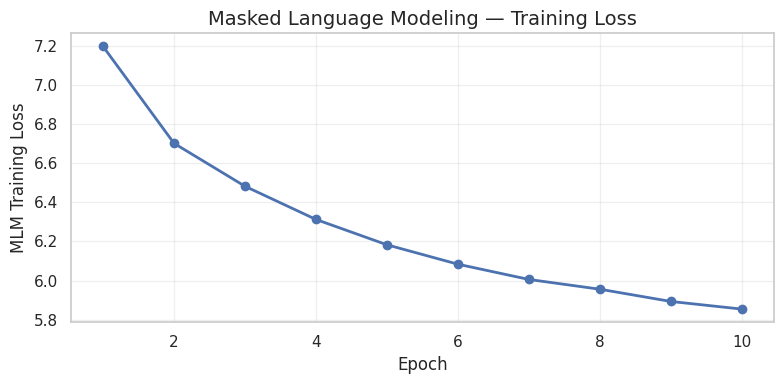

In [51]:
# ANSWER
if mlm_losses:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(range(1, len(mlm_losses) + 1), mlm_losses, marker="o", linewidth=2)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("MLM Training Loss", fontsize=12)
    ax.set_title("Masked Language Modeling — Training Loss", fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Step 4.5: Demonstrate MLM Predictions

Feed a few sentences with `<MASK>` tokens and see what the model predicts.

In [52]:
# ANSWER
# Create an inverse vocabulary dict (index → word) for decoding predictions.
inv_vocab = {idx: word for word, idx in ag_vocab.items()}

def predict_masked(model, sentence_tokens, mask_positions, vocab, inv_vocab, device, top_k=5):
    """Predict masked tokens in a sentence.

    Args:
        model: Trained MLM model.
        sentence_tokens: List of token strings.
        mask_positions: List of int positions to mask.
        vocab: Word-to-index dict.
        inv_vocab: Index-to-word dict.
        device: Torch device.
        top_k: Number of top predictions to show.

    Returns:
        None (prints results).
    """
    # Convert tokens to IDs, masking specified positions
    token_ids = []
    for i, tok in enumerate(sentence_tokens):
        if i in mask_positions:
            token_ids.append(vocab.get(MASK_TOKEN, 1))
        else:
            token_ids.append(vocab.get(tok, vocab.get("<UNK>", 1)))

    input_tensor = torch.tensor([token_ids], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)  # (1, seq_len, vocab_size)

    # Show predictions at masked positions
    masked_display = [f"[{tok}]" if i in mask_positions else tok for i, tok in enumerate(sentence_tokens)]
    print(f"Input: {' '.join(masked_display)}")

    for pos in mask_positions:
        probs = torch.softmax(logits[0, pos], dim=-1)
        top_ids = probs.topk(top_k).indices.tolist()
        top_probs = probs.topk(top_k).values.tolist()
        original = sentence_tokens[pos]
        predictions = [f"{inv_vocab.get(idx, '?')} ({p:.3f})" for idx, p in zip(top_ids, top_probs)]
        print(f"  Position {pos} (original: '{original}'): {', '.join(predictions)}")
    print()

In [53]:
# ANSWER
# Test with some example sentences
if mlm_epochs > 0:
    test_sentences = [
        (["the", "stock", "market", "rose", "sharply", "on", "monday"], [1, 3]),
        (["scientists", "discovered", "a", "new", "planet", "in", "the", "galaxy"], [1, 4]),
        (["the", "team", "won", "the", "championship", "game"], [2, 4]),
    ]

    for tokens, positions in test_sentences:
        predict_masked(mlm_model, tokens, positions, ag_vocab, inv_vocab, accel_device)
else:
    print("Skipping MLM demo (model not trained)")

Input: the [stock] market [rose] sharply on monday
  Position 1 (original: 'stock'): market (0.096), apple (0.033), <UNK> (0.025), us (0.021), consumer (0.018)
  Position 3 (original: 'rose'): market (0.070), in (0.038), the (0.024), data (0.021), for (0.020)

Input: scientists [discovered] a new [planet] in the galaxy
  Position 1 (original: 'discovered'): <UNK> (0.041), of (0.022), to (0.019), scientists (0.019), genes (0.015)
  Position 4 (original: 'planet'): <UNK> (0.035), of (0.033), to (0.020), york (0.017), the (0.017)

Input: the team [won] the [championship] game
  Position 2 (original: 'won'): game (0.169), team (0.025), in (0.022), <UNK> (0.022), the (0.021)
  Position 4 (original: 'championship'): game (0.146), the (0.035), in (0.028), of (0.026), team (0.024)



### Reflective Exercise 4.1

Why is this self-supervised approach (MLM) scalable to the entire internet, whereas the topic classification you did in Sections 2 and 3 is not?

**Answer:**

<br>
This self-supervised approach does not need anyone to label the data. It basically creates its own labels/data through ablasions in the input data, making it easy to automate and scale.
<br>

## Section 5: Fine-Tuning DistilBERT — Pretrained vs. From Scratch

You just trained an MLM model from scratch on AG News headlines. Now imagine training that same objective on **all of Wikipedia and BookCorpus** (~16 GB). That is what BERT did — and DistilBERT is the compressed version that retains 97% of BERT's performance with 40% fewer parameters.

In this section, you fine-tune a pretrained DistilBERT on AG News and compare it to the from-scratch models from Sections 2 and 3.

In [ ]:
show_warning("Section 5 requires substantial compute. It is STRONGLY RECOMMENDED that you run this section on Google Colab with a GPU runtime (preferably an A100 or better). Fine-tuning DistilBERT on AG News for 3 epochs takes ~10-15 min on CPU, ~2-3 min on a GPU (T4), and well under a minute on an A100.")

### Step 5.1: HuggingFace Model Browser

Before we load a model, visit [huggingface.co/models](https://huggingface.co/models) and explore:
1. Filter by task: `text-classification`
2. Search for `distilbert`
3. Browse the top 5 results — compare download counts, licenses, model card descriptions

Note: `distilbert-base-uncased` is the standard starting point (uncased = case-insensitive, lowercase all text). For case-sensitive tasks (e.g., Named Entity Recognition), `distilbert-base-cased` exists.

### Step 5.2: Load Tokenizer and Model

Here is a summary of what these two Hugging Face classes do:

HuggingFace provides the `AutoTokenizer` and `AutoModelForSequenceClassification` classes that automatically select the correct tokenizer and model architecture based on the model name.

#### `AutoTokenizer`
Think of `AutoTokenizer` as the universal translator between human text and the numbers your model expects. It is a "factory" class that automatically loads the correct tokenization algorithm associated with a specific pre-trained model.

* **Vocabulary & Algorithm:** It knows exactly how the model was trained to split words (e.g., using WordPiece for DistilBERT, which breaks "unforgettable" into "un", "##forget", "##table").
* **Special Tokens:** It automatically adds the specific special tokens the model expects, such as `[CLS]` at the beginning and `[SEP]` at the end of sentences.
* **Formatting:** It pads sequences to a uniform length, truncates them if they are too long, and generates the `attention_mask` (a tensor of 1s and 0s) so the model knows which tokens are real and which are just padding.

#### `AutoModelForSequenceClassification`
This is a factory class that loads a pre-trained model architecture specifically adapted for classification tasks (like predicting a sentiment or a topic).

* **Loads Pre-trained Weights:** It downloads and loads the base "body" of the model (e.g., the DistilBERT transformer encoder layers) that already understands language from its pre-training on massive datasets.
* **Attaches a Classification Head:** It discards the original pre-training head (like the Masked Language Modeling head) and attaches a brand new, randomly initialized feed-forward classification layer on top.
* **Task-Ready:** By passing `num_labels=4` (as you did for AG News), it configures that new head to output 4 logits. The model is now perfectly set up to be fine-tuned on your specific downstream dataset.

In [54]:
# Load the DistilBERT tokenizer and model from HuggingFace.
#   Use "distilbert-base-uncased" and set num_labels=4 for AG News.
from transformers import AutoTokenizer, AutoModelForSequenceClassification

hf_model_name = "distilbert-base-uncased"
hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
hf_model = AutoModelForSequenceClassification.from_pretrained(
    hf_model_name, num_labels=AG_NUM_CLASSES
)

# Inspect the model
print(f"Model: {hf_model_name}")
hf_total_params = sum(p.numel() for p in hf_model.parameters())
hf_trainable_params = sum(p.numel() for p in hf_model.parameters() if p.requires_grad)
print(f"Parameters: total={hf_total_params:,}, trainable={hf_trainable_params:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: distilbert-base-uncased
Parameters: total=66,956,548, trainable=66,956,548


### Step 5.3: Tokenize AG News for DistilBERT

DistilBERT uses **WordPiece tokenization** — a subword approach where rare words are broken into known subword units (e.g., "unforgettable" → "un", "##forget", "##table"). This means:
- The vocabulary is different from the word-level vocabulary you've used all semester
- There is almost no `<UNK>` — unknown words are decomposed into known subword pieces
- `##` prefix indicates a continuation subword (it's part of the previous word)

In [55]:
# ANSWER
# Tokenize the AG News dataset for DistilBERT.
#   Use the HuggingFace tokenizer with max_length=128, padding, and truncation.
#   Build a PyTorch Dataset wrapping the tokenized data.
class HFTextDataset(Dataset):
    """PyTorch Dataset for HuggingFace-tokenized text data.

    Wraps tokenized input_ids, attention_mask, and labels for use with
    a standard PyTorch DataLoader.

    Args:
        encodings: Dict with 'input_ids' and 'attention_mask' tensors.
        labels: Tensor of integer labels.
    """

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


# Load raw AG News text (not our pre-tokenized version) for HuggingFace tokenizer
raw_ag = load_dataset("ag_news")

# Subsample if in QUICK mode
if ag_train_samples is not None:
    all_indices = list(range(len(raw_ag["train"])))
    sample_indices = random.sample(all_indices, min(ag_train_samples, len(raw_ag["train"])))
    train_texts = raw_ag["train"].select(sample_indices)
else:
    train_texts = raw_ag["train"]
test_texts = raw_ag["test"]

# Materialize as plain list[str] — HF `datasets` columns can be Arrow/NumPy-backed
# sequences that Transformers does not accept as batch text input.
train_text_list = [str(t) for t in train_texts["text"]]
test_text_list = [str(t) for t in test_texts["text"]]

# Tokenize with the DistilBERT tokenizer
hf_train_enc = hf_tokenizer(
    train_text_list, max_length=128, padding="max_length",
    truncation=True, return_tensors="pt"
)
hf_train_labels = torch.tensor(train_texts["label"], dtype=torch.long)

hf_test_enc = hf_tokenizer(
    test_text_list, max_length=128, padding="max_length",
    truncation=True, return_tensors="pt"
)
hf_test_labels = torch.tensor(test_texts["label"], dtype=torch.long)

# Build Dataset objects
hf_train_dataset = HFTextDataset(hf_train_enc, hf_train_labels)
hf_test_dataset = HFTextDataset(hf_test_enc, hf_test_labels)

print(f"HF train dataset: {len(hf_train_dataset)} examples")
print(f"HF test dataset:  {len(hf_test_dataset)} examples")

# Contrast: show a sample tokenization
sample_text = train_text_list[0][:100]
sample_tokens = hf_tokenizer.tokenize(sample_text)
print(f"\nSample text: '{sample_text}...'")
print(f"WordPiece tokens: {sample_tokens[:20]}...")

HF train dataset: 120000 examples
HF test dataset:  7600 examples

Sample text: 'Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...'
WordPiece tokens: ['wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short', '-', 'sellers', ',', 'wall', 'street']...


### Step 5.4: Fine-Tuning Loop

We use a standard PyTorch training loop (not the HuggingFace `Trainer` class) so you can see exactly what happens during fine-tuning. The key differences from our engine's `Trainer`:
- The model's `.forward()` returns a `SequenceClassifierOutput` object with `.loss` and `.logits`
- We use `AdamW` (weight decay applied correctly) with a linear learning rate warmup
- We pass `input_ids`, `attention_mask`, and `labels` as a dict (the HuggingFace convention)

In [56]:
# ANSWER
# Fine-tune DistilBERT on AG News.
#   Use AdamW optimizer with linear warmup for 10% of training steps.
#   Train for 3 epochs. Log to W&B if enabled.
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    hf_epochs = 3
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    hf_epochs = 2
else:
    hf_epochs = 0

hf_batch_size = 32  # DistilBERT is larger — smaller batch size
hf_lr = 2e-5        # much smaller LR than from-scratch models

hf_train_loader = DataLoader(hf_train_dataset, batch_size=hf_batch_size, shuffle=True)
hf_test_loader = DataLoader(hf_test_dataset, batch_size=64, shuffle=False)

In [57]:
# ANSWER
# Set up AdamW optimizer with linear warmup.
#   Fill in the training loop.
hf_model = hf_model.to(accel_device)
hf_optimizer = optim.AdamW(hf_model.parameters(), lr=hf_lr, weight_decay=0.01)

total_steps = len(hf_train_loader) * hf_epochs
warmup_steps = int(0.1 * total_steps)  # 10% of training for warmup

# Linear warmup + decay scheduler
def lr_lambda(step):
    """Linear warmup for warmup_steps, then linear decay to 0."""
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - step) / float(max(1, total_steps - warmup_steps)))

hf_scheduler = optim.lr_scheduler.LambdaLR(hf_optimizer, lr_lambda=lr_lambda)

In [58]:
# ANSWER
hf_train_losses = []
hf_val_accuracies = []

if hf_epochs > 0:
    hf_start = time.time()

    for epoch in range(hf_epochs):
        # ── Training phase ──
        hf_model.train()
        epoch_loss = 0.0
        num_batches = 0

        for batch in hf_train_loader:
            # Move batch tensors to the accelerator device
            input_ids = batch["input_ids"].to(accel_device)
            attention_mask = batch["attention_mask"].to(accel_device)
            labels = batch["labels"].to(accel_device)

            hf_optimizer.zero_grad()

            # Forward pass — HuggingFace models return an object with .loss and .logits
            #   when labels are provided. Pass input_ids, attention_mask, and labels.
            outputs = hf_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )

            # Extract the loss from the model output and backpropagate
            loss = outputs.loss
            loss.backward()

            # Clip gradients (common practice for fine-tuning)
            torch.nn.utils.clip_grad_norm_(hf_model.parameters(), max_norm=1.0)

            hf_optimizer.step()
            hf_scheduler.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_train_loss = epoch_loss / num_batches
        hf_train_losses.append(avg_train_loss)

        # ── Validation phase ──
        hf_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in hf_test_loader:
                input_ids = batch["input_ids"].to(accel_device)
                attention_mask = batch["attention_mask"].to(accel_device)
                labels = batch["labels"].to(accel_device)

                outputs = hf_model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        hf_val_accuracies.append(val_acc)
        current_lr = hf_scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{hf_epochs} — Loss: {avg_train_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.2e}")

    hf_time = time.time() - hf_start
    print(f"\nDistilBERT fine-tuning time: {hf_time:.1f}s")
else:
    hf_time = 0.0
    print("Skipping DistilBERT fine-tuning (training mode is NONE)")

Epoch 1/3 — Loss: 0.2990, Val Acc: 0.9371, LR: 1.48e-05
Epoch 2/3 — Loss: 0.1419, Val Acc: 0.9454, LR: 7.41e-06
Epoch 3/3 — Loss: 0.0973, Val Acc: 0.9453, LR: 0.00e+00

DistilBERT fine-tuning time: 872.9s


### Step 5.5: Final Three-Way Comparison

In [59]:
# ANSWER
# Build the three-way comparison table:
#   (a) AttentionClassifier from scratch
#   (b) TransformerClassifier (best depth from Section 3) from scratch
#   (c) DistilBERT fine-tuned
final_comparison = {
    "Model": [
        "AttentionClassifier (from scratch)",
        "TransformerClassifier N=2 (from scratch)",
        "DistilBERT (fine-tuned)",
    ],
    "Val Accuracy": [
        attn_results.get("val_accuracy", 0.0) if attn_results else 0.0,
        trans_results.get("val_accuracy", 0.0) if trans_results else 0.0,
        hf_val_accuracies[-1] if hf_val_accuracies else 0.0,
    ],
    "Parameters": [
        f"{total_attn:,}",
        f"{total_trans:,}",
        f"{hf_total_params:,}",
    ],
    "Training Time (s)": [
        f"{attn_time:.1f}",
        f"{trans_time:.1f}",
        f"{hf_time:.1f}",
    ],
}

final_df = pd.DataFrame(final_comparison)
print(final_df.to_string(index=False))

                                   Model  Val Accuracy Parameters Training Time (s)
      AttentionClassifier (from scratch)      0.904737  2,634,820             561.6
TransformerClassifier N=2 (from scratch)      0.919474  2,965,572            3580.2
                 DistilBERT (fine-tuned)      0.945263 66,956,548             872.9


### Reflective Exercise 5.1

The DistilBERT model card says it was trained on BookCorpus + English Wikipedia. The AG News dataset is news articles. Does domain mismatch matter here? Why does DistilBERT still outperform training from scratch despite never having seen news text during pretraining?

**Answer:**

<br>
The domain mismatch does not matter here since BookCorpus + Wikipedia contain diverse and general English. DistilBERT still outperforms training from scratch because the pre-training gives the model general-purpose representations that transfer broadly.
<br>

In [ ]:
show_section()

---
# Challenges

Complete **at least one** challenge. Each challenge builds on the transformer encoder skills from the Lab sections. Challenges 2 and 3 extend the financial time series work from hw11 Challenge 2.

## Challenge 1: Yelp Reviews Full — 5-Class Sentiment with Architecture Sweep

The **Yelp Reviews Full** dataset consists of 650,000 training and 50,000 test reviews. Unlike binary sentiment tasks, this is a **5-class classification problem** based on the star rating (1 to 5).

This task is significantly more difficult because the classes are ordinal and overlapping. A 3-star review often contains both positive and negative sentiments, making it hard for models to distinguish it from a 2-star or 4-star review. Using a Transformer architecture here allows us to see if deeper, context-aware representations can better capture these subtle linguistic nuances over long-form text.

Apply `TransformerClassifier` to the **Yelp Reviews Full** dataset (5-class star rating prediction: 1★ to 5★, ~650K training samples). This is a significantly harder task than AG News: adjacent classes (3★ vs. 4★) are genuinely ambiguous, and the reviews are longer.

### Your task:

1. Load the Yelp Reviews Full dataset via `datasets.load_dataset("yelp_review_full")`
2. Build the text pipeline (tokenize, build vocab, create datasets) using your existing engine
3. Run a **random** W&B sweep (not exhaustive grid) sampling from the following parameter ranges:
   - `num_encoder_layers ∈ {1, 2, 4}`
   - `num_heads ∈ {4, 8}`
   - `dim_feedforward ∈ {512, 1024}`
   - `embedding_dim ∈ {128, 256}`
   - `learning_rate ∈ {0.001, 0.0005, 0.0001}`
   - `dropout ∈ {[0.1], [0.2], [0.3]}`
   - Keep `trainer_batch_size`, `num_epochs`, `vocab_size`, and `padding_idx` fixed
4. Run at least 5 trials (more if using Colab GPU). Subsample to 50K training / 10K test examples for tractable sweep time.
5. Log to W&B project `csci357-hw12-c1`
6. Report the top-5 configurations by validation accuracy
7. Written analysis: which hyperparameter matters most? Does depth help more than heads or FFN width?

**INSTRUCTOR NOTE:** A random sweep is appropriate here — the search space has many dimensions and a full grid would require hundreds of runs. 5–25 random trials reveal the dominant hyperparameters efficiently. Subsample to 50K training examples and run on Colab GPU. Full dataset at 650K will take several hours on CPU even for a single run.

In [ ]:
show_todo("Challenge 1: Yelp Reviews Full Architecture Sweep")

### The Yelp Reviews Full Dataset

The **Yelp Reviews Full** dataset consists of 650,000 training and 50,000 test reviews. Unlike binary sentiment tasks, this is a **5-class classification problem** based on the star rating (1 to 5).

This task is significantly more difficult because the classes are ordinal and overlapping. A 3-star review often contains both positive and negative sentiments, making it hard for models to distinguish it from a 2-star or 4-star review. Using a Transformer architecture here allows us to see if deeper, context-aware representations can better capture these subtle linguistic nuances over long-form text.

> If you were to train on the entire dataset, you should expect a validation accuracy somewhere in the 55% to 62% range. While this might seem low compared to tasks like AG News (where you were getting ~90%), it's actually quite good for this specific dataset! Here is why:
>
> * It's a 5-class problem: Random guessing would only give you a 20% accuracy.
> * Inherent Ambiguity: The classes (1 to 5 stars) are ordinal and highly overlapping. The difference between a 3-star and a 4-star review is often extremely subtle and subjective. Even human readers would frequently disagree on whether a specific review deserves 3 or 4 stars.
> * From-Scratch Training: You are training a relatively small transformer from scratch. State-of-the-art models (like massive pre-trained RoBERTa models) fine-tuned on the entire 650k dataset only max out around 70-72% on this specific benchmark.

So, if your sweep is hitting around the 55%–60% mark on your subsetted example subset, your model is learning exactly as it should!

In [60]:
project_name = "csci357-hw12-c1"

In [61]:
# ANSWER
# Step 1: Load Yelp Reviews Full

from datasets import load_dataset                                                                                                                                                           
                                                                                                                                                                                                
YELP_TRAIN_SAMPLES  = 50000
YELP_TEST_SAMPLES   = 10000                                                                                                                                                                   
YELP_MAX_SEQ_LEN    = 256                                                                                                                                                                     
YELP_NUM_CLASSES    = 5                                                                                                                                                                     
YELP_MAX_VOCAB_SIZE = 30000                                                                                                                                                                   
                                                                                                                                                                                            
yelp_ds = load_dataset("yelp_review_full")                                                                                                                                                  
yelp_raw_train = yelp_ds["train"].select(range(YELP_TRAIN_SAMPLES))                                                                                                                           
yelp_raw_test  = yelp_ds["test"].select(range(YELP_TEST_SAMPLES))                                                                                                                             
                                                                                                                                                                                            
print(f"Yelp train: {len(yelp_raw_train)} examples")                                                                                                                                          
print(f"Yelp test:  {len(yelp_raw_test)} examples")                                                                                                                                         
print(f"Sample: {yelp_raw_train[0]}") 



README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Yelp train: 50000 examples
Yelp test:  10000 examples
Sample: {'label': 4, 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank."}


In [62]:
# ANSWER
# Step 2: Build the text pipeline
import re
from lantern.text import build_vocab
from lantern.data import TextDataset

# Tokenize
def yelp_tokenize(text):                                                                                                                                                                    
    text = text.lower()                                                                                                                                                                     
    text = re.sub(r"[^\w\s\']", "", text)
    return text.split()                                                                                                                                                                       

train_tokens = [yelp_tokenize(sample["text"]) for sample in yelp_raw_train]                                                                                                                   
test_tokens  = [yelp_tokenize(sample["text"]) for sample in yelp_raw_test]


# Build vocabulary from training data
yelp_vocab = build_vocab(train_tokens, max_vocab_size=YELP_MAX_VOCAB_SIZE, min_freq=2)                                                                                                        
YELP_VOCAB_SIZE = len(yelp_vocab)                                                                                                                                                             
print(f"Vocabulary: {YELP_VOCAB_SIZE} words")                                                                                                                                               
                                                                                                                                                                                            
def encode(tokens, vocab):                                                                                                                                                                    
    return [vocab.get(t, vocab["<UNK>"]) for t in tokens]                                                                                                                                   
                                                                                                                                                                                            
train_ids = [encode(toks, yelp_vocab) for toks in train_tokens]                                                                                                                               
test_ids  = [encode(toks, yelp_vocab) for toks in test_tokens]                                                                                                                              
                                                                                                                                                                                            
train_labels = [sample["label"] for sample in yelp_raw_train]                                                                                                                               
test_labels  = [sample["label"] for sample in yelp_raw_test]



# Convert to tensor datasets
yelp_train_data = TextDataset(train_ids, train_labels)                                                                                                                                        
yelp_test_data  = TextDataset(test_ids,  test_labels)                                                                                                                                       
                                                                                                                                                                                            
print(f"Yelp train dataset: {len(yelp_train_data)} examples")
print(f"Yelp test dataset:  {len(yelp_test_data)} examples")



Vocabulary: 30002 words
Yelp train dataset: 50000 examples
Yelp test dataset:  10000 examples


In [65]:
# ANSWER
# Step 3: Configure and run the sweep
yelp_sweep_config = {
    "method": "random",  # Changed to random search for a larger parameter space
    "parameters": {
        "model_type": {"value": "texttransformer"},
        "num_encoder_layers": {"values": [1, 2, 4]},
        "num_heads": {"values": [4, 8]},  # 4 and 8 heads usually work better than 2
        "dim_feedforward": {"values": [512, 1024]},
        "embedding_dim": {"values": [128, 256]},  # Increased capacity
        "vocab_size": {"value": YELP_VOCAB_SIZE},
        "padding_idx": {"value": 0},
        "max_seq_len": {"value": 256},
        "hidden_units": {"values": [[64], [128]]},  # Try a larger classification head
        "dropout": {"values": [[0.1], [0.2], [0.3]]},  # Explore dropout to prevent overfitting
        "trainer_batch_size": {"value": 64},
        "learning_rate": {"values": [0.001, 0.0005, 0.0001]},  # LR is critical for Transformers
        "num_epochs": {"value": 5},
    },
}

if DO_WANDB_LOGGING and num_epochs_lab > 0:
    yelp_train_fn = make_train_sweep(
        wandb_project_name=project_name,
        datasets=(yelp_train_data, yelp_test_data),
        device=accel_device,
        input_spec=0,
        num_outputs=YELP_NUM_CLASSES,
        text_collate_fn=text_collate_fn,
        wandb_entity_name=entity,
        wandb_name_prefix=user_initials,
        metrics_config_param=MetricsConfig(task="multiclass", names=["accuracy"]),
    )

    yelp_sweep_id = wandb.sweep(yelp_sweep_config, project=project_name, entity=entity)
    wandb.agent(yelp_sweep_id, function=yelp_train_fn, count=5)
    print(f"Yelp sweep complete! Sweep ID: {yelp_sweep_id}")
else:
    print("Skipping Yelp sweep")
    yelp_sweep_id = None

Create sweep with ID: c2a7n8tv
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw12-c1/sweeps/c2a7n8tv


wandb: Agent Starting Run: i5sc9udo with config:
wandb: 	dim_feedforward: 512
wandb: 	dropout: [0.2]
wandb: 	embedding_dim: 128
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.0001
wandb: 	max_seq_len: 256
wandb: 	model_type: texttransformer
wandb: 	num_encoder_layers: 2
wandb: 	num_epochs: 5
wandb: 	num_heads: 8
wandb: 	padding_idx: 0
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 30002
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dim_feedforward': 512, 'dropout': [0.2], 'embedding_dim': 128, 'hidden_units': [64], 'learning_rate': 0.0001, 'max_seq_len': 256, 'model_type': 'texttransformer', 'num_encoder_layers': 2, 'num_epochs': 5, 'num_heads': 8, 'padding_idx': 0, 'trainer_batch_size': 64, 'vocab_size': 30002}
Run name set to: CMB_texttransformer_bs64_lr0.00010_ed128_nh8_nl2_dff512_wd0.00000


/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/model.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  


Epoch 0:
Train Accuracy=28.15%  Val Accuracy=37.41%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 1:
Train Accuracy=42.11%  Val Accuracy=45.67%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 2:
Train Accuracy=46.53%  Val Accuracy=47.08%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 3:
Train Accuracy=48.31%  Val Accuracy=48.62%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 4:
Train Accuracy=50.02%  Val Accuracy=49.98%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
--> Saving checkpoint: ./

...

Run complete! val_accuracy: 55.28%


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 12379qgf with config:
wandb: 	dim_feedforward: 1024
wandb: 	dropout: [0.1]
wandb: 	embedding_dim: 128
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.0001
wandb: 	max_seq_len: 256
wandb: 	model_type: texttransformer
wandb: 	num_encoder_layers: 4
wandb: 	num_epochs: 5
wandb: 	num_heads: 8
wandb: 	padding_idx: 0
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 30002
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dim_feedforward': 1024, 'dropout': [0.1], 'embedding_dim': 128, 'hidden_units': [64], 'learning_rate': 0.0001, 'max_seq_len': 256, 'model_type': 'texttransformer', 'num_encoder_layers': 4, 'num_epochs': 5, 'num_heads': 8, 'padding_idx': 0, 'trainer_batch_size': 64, 'vocab_size': 30002}
Run name set to: CMB_texttransformer_bs64_lr0.00010_ed128_nh8_nl4_dff1024_wd0.00000
Epoch 0:
Train Accuracy=34.29%  Val Accuracy=43.38%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 1:
Train Accuracy=45.73%  Val Accuracy=47.85%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 2:
Train Accuracy=49.30%  Val Accuracy=50.08%
--> New best checkpoint saved: ./checkpoints/csci357-hw12-c1-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw12-c1-last.pt
Epoch 3:
Train Accuracy=51.3

epoch,▁▃▅▆█
train_accuracy,▁▅▇██
val_accuracy,▁▅▇▇█
epoch,4
train_accuracy,0.52611
val_accuracy,0.51774


Run complete! val_accuracy: 51.77%
Yelp sweep complete! Sweep ID: c2a7n8tv


In [66]:
# ANSWER
# Step 4: Retrieve and analyze results
if yelp_sweep_id and DO_WANDB_LOGGING:
    api = wandb.Api()
    # Fix: Use yelp_sweep_id instead of sweep_id
    runs = api.runs(f"{entity}/{project_name}", filters={"sweep": yelp_sweep_id})

    print(f"Retrieved {len(runs)} runs from sweep {yelp_sweep_id}")

    if len(runs) > 0:
        yelp_results = []
        for run in runs:
            summary = run.summary
            config = run.config

            yelp_results.append({
                "layers": config.get("num_encoder_layers"),
                "heads": config.get("num_heads"),
                "d_ff": config.get("dim_feedforward"),
                "val_accuracy": summary.get("val_accuracy", 0.0),
            })

        yelp_df = pd.DataFrame(yelp_results).sort_values("val_accuracy", ascending=False)
        print("Top 5 configurations:")
        print(yelp_df.head().to_string(index=False))
        print(f"\nBest accuracy: {yelp_df['val_accuracy'].max():.4f}")
        print(f"Random baseline (5-class): {1/5:.4f}")
    else:
        print("No runs found for this sweep ID.")

Retrieved 5 runs from sweep c2a7n8tv
Top 5 configurations:
 layers  heads  d_ff  val_accuracy
      4      8   512      0.552835
      4      4  1024      0.547309
      4      4   512      0.530387
      4      8  1024      0.517740
      2      8   512      0.499847

Best accuracy: 0.5528
Random baseline (5-class): 0.2000


### Challenge 1 Written Analysis

**Answer:**

<br>
For the Yelp dataset, we can see that increasing the number of layers, heads, and FFN dimension helped increase the val accuracy. This performs much better than the random baseline of 0.2 (just guessing 1 category for all samples).
<br>

## Challenge 2: MSFT Direction Prediction — Binary Classification with Transformer Encoder

Revisit the self-attention time series predictor from hw11 Challenge 2, but replace the single attention layer with a full transformer encoder stack. Use MSFT (Microsoft) stock data via `yfinance`.

### Feature Engineering (5 features)
- `log_return`: $r_t = \ln(P_t^{close} / P_{t-1}^{close})$
- `log_volume`: $\ln(\text{Volume}_t)$
- `log_intraday_chg`: $\ln(P_t^{close} / P_t^{open})$
- `log_high_low`: $\ln(P_t^{high} / P_t^{low})$ — intraday volatility proxy
- `volatility_5d`: 5-day rolling standard deviation of `log_return`

Scale all five with `StandardScaler` fit on training data only. Use a 30-day sliding window.

### Architecture
A local `TimeSeriesTransformerClassifier` — `nn.Linear(num_features → embed_dim)` input projection → `PositionalEncoding` → `nn.TransformerEncoder` → mean pool → FC head (Binary CE). **Not in engine** — define locally in this notebook.

### Controlled Comparisons
1. Univariate (`log_return` only) vs. multivariate (all 5 features)
2. N=1 (single encoder layer / attention-only baseline) vs. N=2 vs. N=4 transformer encoder

### Deliverable
2×3 comparison table (2 feature sets × 3 architecture depths), learning curves, written analysis.

**INSTRUCTOR NOTE:** Financial time series is inherently noisy. Expect ~50–55% accuracy (barely above random for binary). The point is comparing architectures, not beating the market. Students from hw11 Challenge 2 will have the feature engineering ready — others must build it from scratch.

In [ ]:
show_todo("Challenge 2: MSFT Direction Prediction with Transformer Encoder")

[*********************100%***********************]  1 of 1 completed

Downloaded 1258 trading days
Price            Close        High         Low        Open    Volume
Date                                                                
2020-01-02  152.158386  152.262592  149.989032  150.415323  22622100
2020-01-03  150.263733  151.523669  149.733237  149.979549  21116200
2020-01-06  150.652115  150.718434  148.264867  148.804846  20813700
2020-01-07  149.278580  151.258474  149.032282  150.926921  21634100
2020-01-08  151.656296  152.328899  149.629034  150.557402  27746500


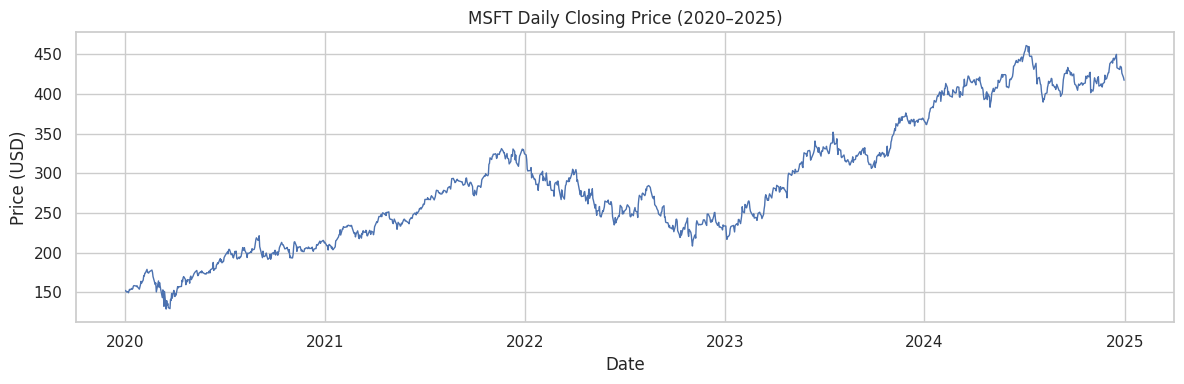

In [67]:
# ANSWER
import yfinance as yf
from sklearn.preprocessing import StandardScaler

# Download ~5 years of daily data for MSFT
msft_raw = yf.download("MSFT", start="2020-01-01", end="2025-01-01", auto_adjust=True)
msft_raw.columns = msft_raw.columns.get_level_values(0)
close = msft_raw["Close"].squeeze().dropna()

# yfinance may return multi-level columns; flatten if needed

print(f"Downloaded {len(msft_raw)} trading days")
print(msft_raw.head())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(close.index, close.values, linewidth=1.0)
ax.set_title("MSFT Daily Closing Price (2020–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()


In [69]:
# ANSWER
# Feature engineering

df = pd.DataFrame(index=msft_raw.index)
open_ = msft_raw["Open"].squeeze().dropna()
high = msft_raw["High"].squeeze().dropna()
low = msft_raw["Low"].squeeze().dropna()
vol = msft_raw["Volume"].squeeze().dropna()

df["log_return"] = np.log(close / close.shift(1))
df["log_volume"] = np.log(vol.astype(np.float32))
df["log_intraday_chg"] = np.log(close / open_)
df["log_high_low"]    = np.log(high / low)
df["volatility_5d"] = df["log_return"].rolling(5).std()
df["target"] = (df["log_return"].shift(-1) > 0).astype(int)
df = df.dropna()

feature_cols = ["log_return", "log_volume", "log_intraday_chg", "log_high_low", "volatility_5d"]
msft = df.copy()    
print(msft[feature_cols].describe())



print(f"Samples after feature engineering: {len(msft)}")
print(f"Class distribution: {msft['target'].value_counts().to_dict()}")

        log_return   log_volume  log_intraday_chg  log_high_low  volatility_5d
count  1253.000000  1253.000000       1253.000000   1253.000000    1253.000000
mean      0.000808    17.093266          0.000334      0.021374       0.016478
std       0.019248     0.379753          0.014578      0.012103       0.011132
min      -0.159454    15.784649         -0.061074      0.006017       0.001514
25%      -0.008146    16.833645         -0.007807      0.013367       0.009725
50%       0.001110    17.054224          0.000845      0.018310       0.013860
75%       0.010881    17.313244          0.009187      0.025936       0.020261
max       0.132929    18.390352          0.077909      0.140198       0.122156
Samples after feature engineering: 1253
Class distribution: {1: 661, 0: 592}


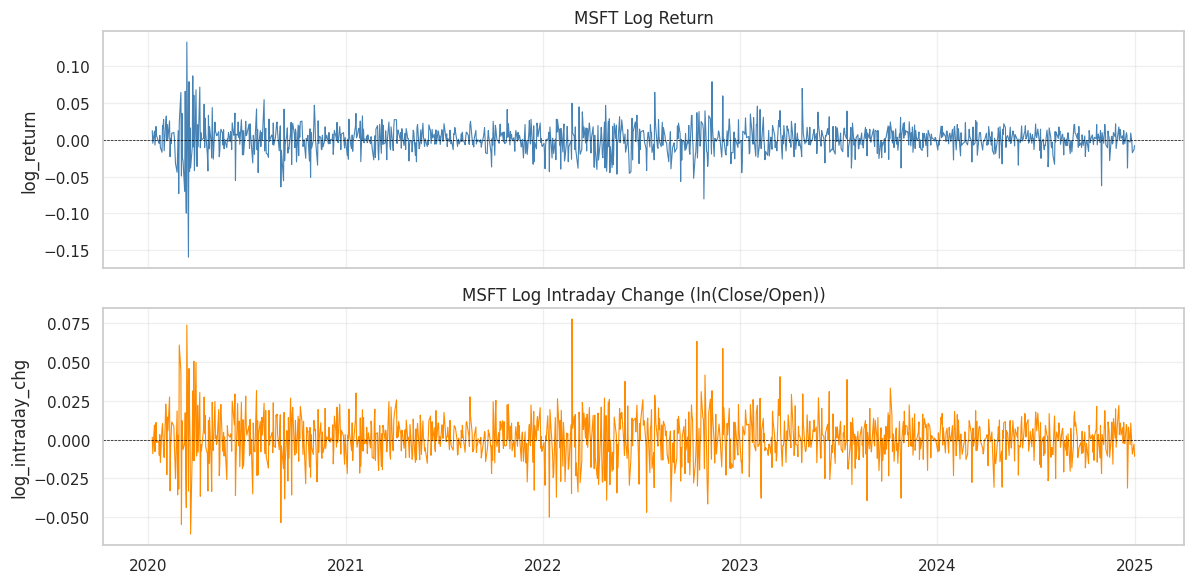

In [71]:
import matplotlib.pyplot as plt

# Plot the log_return and log_intraday_chg
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)                                                                                                                                  
axes[0].plot(msft.index, msft["log_return"], linewidth=0.8, color="steelblue")
axes[0].set_title("MSFT Log Return")                                                                                                                                                          
axes[0].set_ylabel("log_return")                                                                                                                                                            
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")                                                                                                                              
axes[0].grid(True, alpha=0.3)                                                                                                                                                                 

axes[1].plot(msft.index, msft["log_intraday_chg"], linewidth=0.8, color="darkorange")                                                                                                         
axes[1].set_title("MSFT Log Intraday Change (ln(Close/Open))")                                                                                                                              
axes[1].set_ylabel("log_intraday_chg")                                                                                                                                                        
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")                                                                                                                            
axes[1].grid(True, alpha=0.3)                                                                                                                                                                 
                                                                                                                                                                                            
plt.tight_layout()                                                                                                                                                                            
plt.show()

In [72]:
# ANSWER
# Create sliding window dataset
WINDOW_SIZE = 30
TRAIN_SPLIT  = 0.8

# Scale features
features_raw = msft[feature_cols].values.astype(np.float32)
targets_raw = msft["target"].values.astype(np.int64)
n_windows = len(features_raw) - WINDOW_SIZE
split_idx = int(n_windows * TRAIN_SPLIT)

# Fit scaler on train
scaler = StandardScaler()
scaler.fit(features_raw[:split_idx + WINDOW_SIZE])
features = scaler.transform(features_raw)

# Build windows
X_all, y_all = [], []
for i in range(n_windows):
    X_all.append(features[i:i+WINDOW_SIZE])
    y_all.append(targets_raw[i + WINDOW_SIZE])

X_all = np.array(X_all) # (window, WINDOW_SIZE, n_features)
y_all = np.array(y_all) # label at end of window

# Univariate: log return only (feature index 0)
X_uni_train = X_all[:split_idx, :, 0:1]
X_uni_test = X_all[split_idx:, :, 0:1]
y_uni_train = y_all[:split_idx]
y_uni_test = y_all[split_idx:]

# Multivariate: all 5 features
X_multi_train = X_all[:split_idx]
X_multi_test = X_all[split_idx:]
y_multi_train = y_all[:split_idx]
y_multi_test = y_all[split_idx:]


print(f"Univariate — Train: {X_uni_train.shape}, Test: {X_uni_test.shape}")
print(f"Multivariate — Train: {X_multi_train.shape}, Test: {X_multi_test.shape}")

Univariate — Train: (978, 30, 1), Test: (245, 30, 1)
Multivariate — Train: (978, 30, 5), Test: (245, 30, 5)


In [73]:
# ANSWER
# Define the local TimeSeriesTransformerClassifier
from lantern.model import PositionalEncoding
import math
import torch.nn as nn

class TimeSeriesTransformerClassifier(nn.Module):
    """Transformer encoder for time series classification.

    Architecture:
        Input (batch, window, num_features)
        -> nn.Linear(num_features, embed_dim) input projection
        -> PositionalEncoding
        -> nn.TransformerEncoder (N layers)
        -> Mean pool over time dimension
        -> FC classification head

    Args:
        num_features (int): Number of input features per time step.
        embed_dim (int): Model dimension after input projection.
        num_heads (int): Number of attention heads.
        num_layers (int): Number of transformer encoder layers.
        dim_feedforward (int): FFN hidden dimension.
        num_classes (int): Number of output classes.
        dropout (float): Dropout rate.
    """

    def __init__(self, num_features, embed_dim, num_heads, num_layers,
                 dim_feedforward, num_classes, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(num_features, embed_dim)
        self.pos_enc = PositionalEncoding(embed_dim, max_len=5000, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(embed_dim, num_classes)


    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x.mean(dim=1) # Mean pool over time
        return self.head(x)
        

In [78]:
# ANSWER
# Training helper function for time series models

def train_ts_model(model, X_train, y_train, X_test, y_test, device,
                   epochs=20, batch_size=32, lr=0.001):
    model = model.to(device)
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_te = torch.tensor(y_test, dtype=torch.long).to(device)
    
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total  = 0.0, 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct += (out.argmax(1) == y_b).sum().item()
            total += len(y_b)
            
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = model(X_b)
                loss = criterion(out, y_b)
                val_loss += loss.item() * len(y_b)
                val_correct += (out.argmax(1) == y_b).sum().item()
                val_total += len(y_b)
                
        history["train_loss"].append(total_loss / total)
        history["val_loss"].append(val_loss / val_total)
        history["train_acc"].append(correct / total)
        history["val_acc"].append(val_correct / val_total)
        print(f"Epoch {epoch}: train acc: {correct / total}, val acc: {val_correct / val_total}")
        
    return history["train_acc"][-1], history["val_acc"][-1], history

In [79]:
# ANSWER
# Run 2x2 comparison: features & architecture depth
ts_epochs = 50 if RUN_TRAINING_MODE != RunTrainingMode.NONE else 0

c2_results = {}
c2_histories = {}


for feat_name, X_tr, y_tr, X_te, y_te, n_feat in [
    ("Univariate", X_uni_train, y_uni_train, X_uni_test, y_uni_test, 1),
    ("Multivariate", X_multi_train, y_multi_train, X_multi_test, y_multi_test, 5),
]:
    for n_layers, label in [(1, "Attention (N=1)"), (2, "Transformer (N=2)"), (4, "Transformer (N=4)")]:
        model = TimeSeriesTransformerClassifier(
            num_features=n_feat,
            embed_dim=128,
            num_heads=4,
            num_layers=n_layers,
            dim_feedforward=512,
            num_classes=2,
            dropout=0.2
        )
        if ts_epochs > 0:
            # Unpack both training and validation accuracies along with history
            train_acc, val_acc, history = train_ts_model(
                model, X_tr, y_tr, X_te, y_te,
                accel_device,
                lr=0.00025,
                epochs=ts_epochs)
        else:
            train_acc, val_acc, history = 0.0, 0.0, {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

        c2_results[(feat_name, label)] = val_acc
        c2_histories[(feat_name, label)] = history
        print(f"{feat_name} | {label}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

Epoch 0: train acc: 0.5286298568507157, val acc: 0.5102040816326531
Epoch 1: train acc: 0.5143149284253579, val acc: 0.5346938775510204
Epoch 2: train acc: 0.49795501022494887, val acc: 0.5346938775510204
Epoch 3: train acc: 0.516359918200409, val acc: 0.5346938775510204
Epoch 4: train acc: 0.5143149284253579, val acc: 0.5061224489795918
Epoch 5: train acc: 0.5245398773006135, val acc: 0.5102040816326531
Epoch 6: train acc: 0.50920245398773, val acc: 0.46530612244897956
Epoch 7: train acc: 0.5306748466257669, val acc: 0.46530612244897956
Epoch 8: train acc: 0.5, val acc: 0.5061224489795918
Epoch 9: train acc: 0.516359918200409, val acc: 0.5346938775510204
Epoch 10: train acc: 0.5051124744376279, val acc: 0.5102040816326531
Epoch 11: train acc: 0.49693251533742333, val acc: 0.5346938775510204
Epoch 12: train acc: 0.5204498977505112, val acc: 0.5346938775510204
Epoch 13: train acc: 0.5, val acc: 0.49795918367346936
Epoch 14: train acc: 0.5010224948875256, val acc: 0.5265306122448979
Epoc

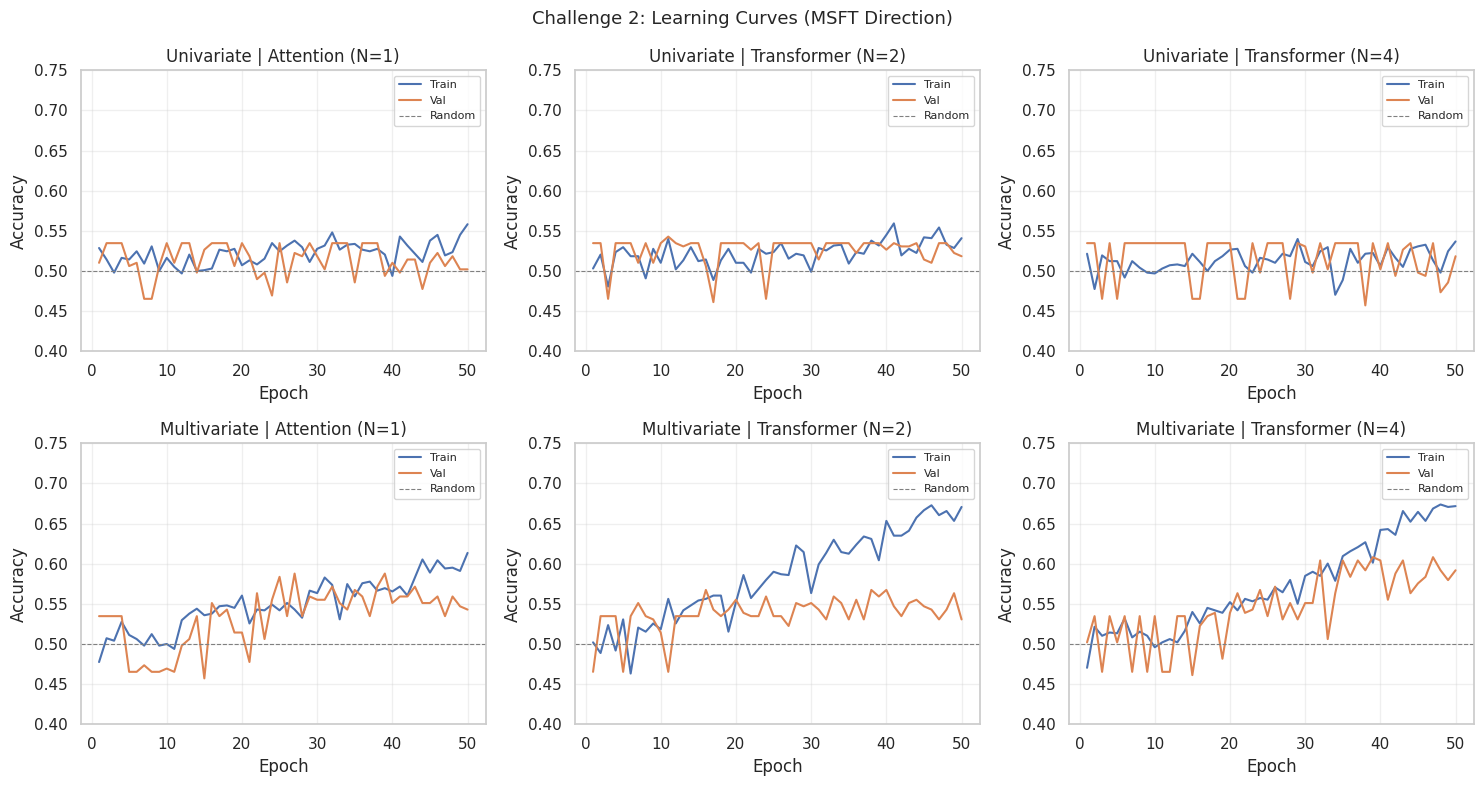

In [80]:
# Generate plots!
feat_names   = ["Univariate", "Multivariate"]                                                                                                                                                 
layer_labels = ["Attention (N=1)", "Transformer (N=2)", "Transformer (N=4)"]                                                                                                                  

fig, axes = plt.subplots(2, 3, figsize=(15, 8))                                                                                                                                               
for row, feat_name in enumerate(feat_names):                                                                                                                                                
    for col, label in enumerate(layer_labels):                                                                                                                                                
        ax   = axes[row][col]                                                                                                                                                               
        hist = c2_histories[(feat_name, label)]                                                                                                                                               
        ep   = range(1, len(hist["train_acc"]) + 1)
        ax.plot(ep, hist["train_acc"], label="Train")                                                                                                                                         
        ax.plot(ep, hist["val_acc"],   label="Val")                                                                                                                                         
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random")                                                                                                          
        ax.set_title(f"{feat_name} | {label}")                                                                                                                                                
        ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")                                                                                                                                     
        ax.set_ylim(0.4, 0.75)                                                                                                                                                                
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)                                                                                                                                     
                                                                                                                                                                                            
plt.suptitle("Challenge 2: Learning Curves (MSFT Direction)", fontsize=13)                                                                                                                  
plt.tight_layout()                                                                                                                                                                            
plt.show() 


In [81]:
# Build a comparison table

rows = []
for (feat_name, label), val_acc in c2_results.items():
    rows.append({"Features": feat_name, "Architecture": label, "Val Accuracy": val_acc})                                                                                                      

c2_df = (pd.DataFrame(rows)                                                                                                                                                                   
            .pivot(index="Features", columns="Architecture", values="Val Accuracy")                                                                                                          
            .reindex(columns=["Attention (N=1)", "Transformer (N=2)", "Transformer (N=4)"]))                                                                                                   
                                                                                                                                                                                            
print("Challenge 2: 2×3 Comparison Table (Val Accuracy)")
print(c2_df.round(4).to_string())                                                                                                                                                             
print(f"\nRandom baseline (binary): 0.5000")



Challenge 2: 2×3 Comparison Table (Val Accuracy)
Architecture  Attention (N=1)  Transformer (N=2)  Transformer (N=4)
Features                                                           
Multivariate           0.5429             0.5306             0.5918
Univariate             0.5020             0.5184             0.5184

Random baseline (binary): 0.5000


### Challenge 2 Reflection

**Answer:**



<br>
We can see that the multivariate case improved the accuracy. This indicates that the features that we engineered were important in determining the direction of the closing price. With the univariate case, we slightly improved the accuracy by adding more transformer blocks, but it did not increase it much. Increasing the number of the transformer blocks also helped for the multivariate case (though it decreased for N=2).
<br>

## Challenge 3: MSFT Log Return Forecasting — Regression with Transformer Encoder

Extend the MSFT transformer from Challenge 2 to predict the next-day **log return** ($r_{t+1}$) as a continuous value rather than a binary direction.

**Why log returns?** Log returns have three desirable properties: (1) **time additivity** — the multi-day log return is the sum of daily log returns, (2) **symmetry** — a +5% gain and -5% loss have symmetric magnitudes, and (3) **approximate normality** — log returns are closer to Gaussian than raw price changes.

### Architecture
Same base as Challenge 2, but:
- Final FC head outputs a **single scalar** (regression)
- Loss: **MSE** (Mean Squared Error)
- Evaluation metric: MSE + directional accuracy (does the predicted sign match the actual sign?)

### Controlled Comparisons
Univariate vs. multivariate; N=2 vs. N=4 encoder layers.

In [ ]:
show_todo("Challenge 3: MSFT Log Return Regression")

In [82]:
class TimeSeriesTransformerRegressor(nn.Module):                                                                                                                                              
    """Same encoder stack as C2 but outputs one scalar (log-return forecast)."""                                                                                                              
    def __init__(self, num_features, embed_dim, num_heads, num_layers,                                                                                                                        
                dim_feedforward, dropout=0.1):                                                                                                                                               
        super().__init__()                                                                                                                                                                    
        self.input_proj = nn.Linear(num_features, embed_dim)                                                                                                                                  
        self.pos_enc = PositionalEncoding(embed_dim, max_len=5000, dropout=dropout)                                                                                                      
        encoder_layer = nn.TransformerEncoderLayer(                                                                                                                                         
            d_model=embed_dim, nhead=num_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation="gelu",                                                                                                                             
        )                                                                                                                                                                                   
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)                                                                                                            
        self.dropout = nn.Dropout(dropout)                                                                                                                                                    
        self.head = nn.Linear(embed_dim, 1)
                                                                                                                                                                                            
    def forward(self, x):                                                                                                                                                                   
        x = self.input_proj(x)
        x = self.pos_enc(x)                                                                                                                                                                   
        x = self.encoder(x)
        x = x.mean(dim=1)                                                                                                                                                                     
        x = self.dropout(x)                                                                                                                                                                 
        return self.head(x).squeeze(-1)   # (batch,)


def train_ts_regressor(model, X_train, y_train, X_test, y_test, device,
                         epochs=50, batch_size=32, lr=0.001):
    model = model.to(device)
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test,  dtype=torch.float32)
    y_te = torch.tensor(y_test,  dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = {"train_mse": [], "val_mse": [], "val_dir_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_b)

        model.eval()
        val_loss, all_preds, all_targets = 0.0, [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                pred = model(X_b)
                val_loss += criterion(pred, y_b).item() * len(y_b)
                all_preds.append(pred)
                all_targets.append(y_b)

        all_preds   = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        val_mse     = val_loss / len(X_test)
        val_dir_acc = ((all_preds > 0) == (all_targets > 0)).float().mean().item()

        history["train_mse"].append(total_loss / len(X_train))
        history["val_mse"].append(val_mse)
        history["val_dir_acc"].append(val_dir_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train MSE: {total_loss/len(X_train):.6f} | "
                f"Val MSE: {val_mse:.6f} | Dir Acc: {val_dir_acc:.4f}")

    return history["val_mse"][-1], history["val_dir_acc"][-1], history



# Build regression windows (target is next-day log return, unscaled)
log_return_unscaled = msft_raw.loc[msft.index, "Close"].squeeze()
log_return_unscaled = np.log(log_return_unscaled / log_return_unscaled.shift(1)).values.astype(np.float32)
y_reg_all = np.array([log_return_unscaled[i + WINDOW_SIZE] for i in range(n_windows)], dtype=np.float32)


X_uni_train_reg = X_uni_train
X_uni_test_reg = X_uni_test
X_multi_train_reg = X_multi_train 
X_multi_test_reg = X_multi_test
y_uni_train_reg = y_reg_all[:split_idx]
y_uni_test_reg   = y_reg_all[split_idx:]
y_multi_train_reg = y_reg_all[:split_idx]
y_multi_test_reg = y_reg_all[split_idx:]

c3_results = {}
c3_histories = {}
c3_epochs = 50 if RUN_TRAINING_MODE != RunTrainingMode.NONE else 0


for feat_name, X_tr, y_tr, X_te, y_te, n_feat in [                                                                                                                                            
    ("Univariate",   X_uni_train_reg,   y_uni_train_reg,   X_uni_test_reg,   y_uni_test_reg,   1),                                                                                            
    ("Multivariate", X_multi_train_reg, y_multi_train_reg, X_multi_test_reg, y_multi_test_reg, 5),                                                                                            
]:                                                                                                                                                                                          
    for n_layers in [2, 4]:                                                                                                                                                                   
        label = f"Transformer (N={n_layers})"                                                                                                                                               
        model = TimeSeriesTransformerRegressor(                                                                                                                                               
            num_features=n_feat, embed_dim=128, num_heads=4,                                                                                                                                
            num_layers=n_layers, dim_feedforward=512, dropout=0.2,                                                                                                                            
        )                                                                                                                                                                                     
        if c3_epochs > 0:
            val_mse, val_dir_acc, hist = train_ts_regressor(                                                                                                                                  
                model, X_tr, y_tr, X_te, y_te, accel_device,                                                                                                                                  
                epochs=c3_epochs, lr=0.00025,
            )                                                                                                                                                                                 
        else:                                                                                                                                                                               
            val_mse, val_dir_acc = 0.0, 0.0                                                                                                                                                   
            hist = {"train_mse": [], "val_mse": [], "val_dir_acc": []}                                                                                                                        

        c3_results[(feat_name, label)]   = (val_mse, val_dir_acc)                                                                                                                             
        c3_histories[(feat_name, label)] = hist                                                                                                                                             
        print(f"{feat_name} | {label}: Val MSE = {val_mse:.6f}, Dir Acc = {val_dir_acc:.4f}")

Epoch  10/50 | Train MSE: 0.001663 | Val MSE: 0.000292 | Dir Acc: 0.5388
Epoch  20/50 | Train MSE: 0.000956 | Val MSE: 0.000163 | Dir Acc: 0.5429
Epoch  30/50 | Train MSE: 0.000779 | Val MSE: 0.000258 | Dir Acc: 0.4612
Epoch  40/50 | Train MSE: 0.000777 | Val MSE: 0.000502 | Dir Acc: 0.4612
Epoch  50/50 | Train MSE: 0.000643 | Val MSE: 0.000161 | Dir Acc: 0.4939
Univariate | Transformer (N=2): Val MSE = 0.000161, Dir Acc = 0.4939
Epoch  10/50 | Train MSE: 0.001514 | Val MSE: 0.000191 | Dir Acc: 0.4653
Epoch  20/50 | Train MSE: 0.000744 | Val MSE: 0.000169 | Dir Acc: 0.5388
Epoch  30/50 | Train MSE: 0.000717 | Val MSE: 0.000172 | Dir Acc: 0.5388
Epoch  40/50 | Train MSE: 0.000562 | Val MSE: 0.000159 | Dir Acc: 0.5510
Epoch  50/50 | Train MSE: 0.000657 | Val MSE: 0.000159 | Dir Acc: 0.5306
Univariate | Transformer (N=4): Val MSE = 0.000159, Dir Acc = 0.5306
Epoch  10/50 | Train MSE: 0.002240 | Val MSE: 0.000192 | Dir Acc: 0.5673
Epoch  20/50 | Train MSE: 0.000907 | Val MSE: 0.000174 | Di

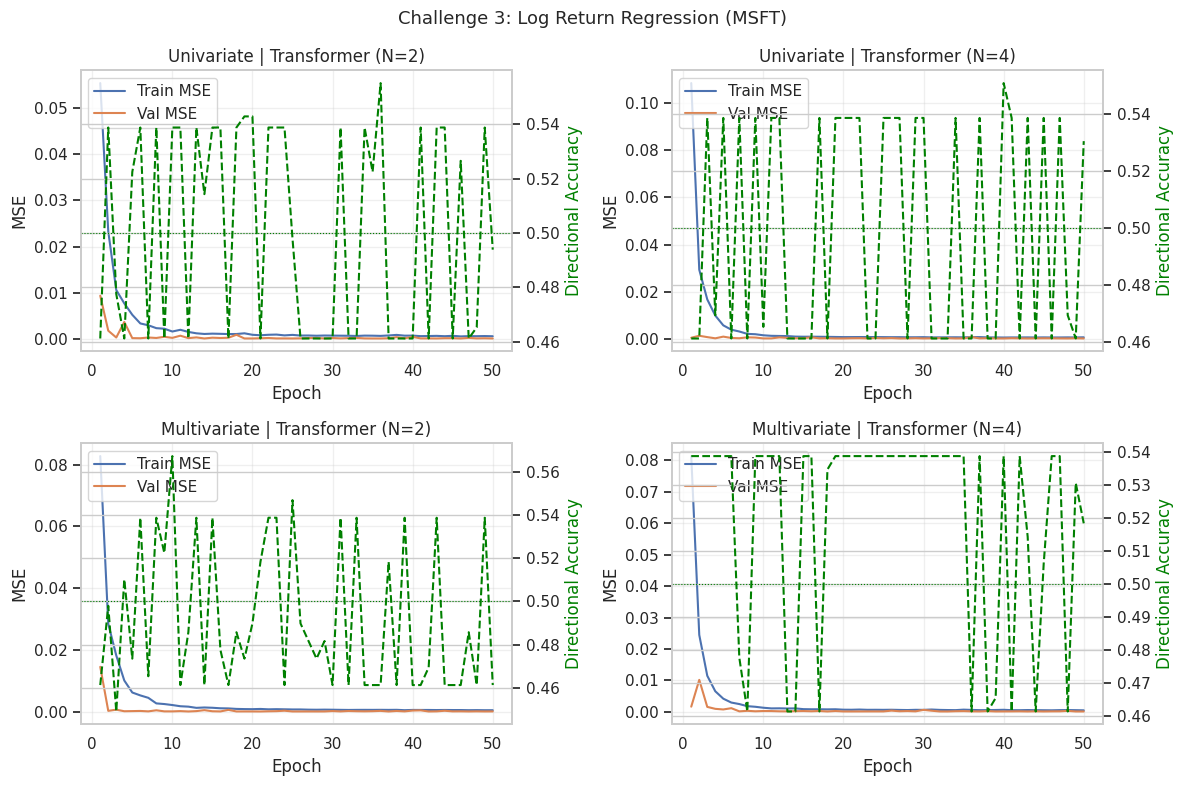


Challenge 3: 2×2 Comparison Table
    Features      Architecture  Val MSE  Dir Acc
  Univariate Transformer (N=2) 0.000161   0.4939
  Univariate Transformer (N=4) 0.000159   0.5306
Multivariate Transformer (N=2) 0.000179   0.4612
Multivariate Transformer (N=4) 0.000160   0.5184

Random baseline (directional): 0.5000


In [83]:
# ANSWER — Challenge 3 results                                                                                                                                                              
                                                                                                                                                                                                
# Learning curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))                                                                                                                                               
feat_names   = ["Univariate", "Multivariate"]                                                                                                                                                 
layer_labels = ["Transformer (N=2)", "Transformer (N=4)"]
                                                                                                                                                                                            
for row, feat_name in enumerate(feat_names):                                                                                                                                                
    for col, label in enumerate(layer_labels):                                                                                                                                                
        ax   = axes[row][col]                                                                                                                                                               
        hist = c3_histories[(feat_name, label)]
        ep   = range(1, len(hist["val_mse"]) + 1)                                                                                                                                             
        ax.plot(ep, hist["train_mse"], label="Train MSE")
        ax.plot(ep, hist["val_mse"],   label="Val MSE")                                                                                                                                       
        ax2 = ax.twinx()                                                                                                                                                                    
        ax2.plot(ep, hist["val_dir_acc"], color="green", linestyle="--", label="Dir Acc")                                                                                                     
        ax2.set_ylabel("Directional Accuracy", color="green")                                                                                                                                 
        ax2.axhline(0.5, color="green", linestyle=":", linewidth=0.8)
        ax.set_title(f"{feat_name} | {label}")                                                                                                                                                
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")                                                                                                                                          
        ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)                                                                                                                                 
                                                                                                                                                                                            
plt.suptitle("Challenge 3: Log Return Regression (MSFT)", fontsize=13)                                                                                                                      
plt.tight_layout()                                                                                                                                                                            
plt.show()                                                                                                                                                                                  
                                                                                                                                                                                            
# Comparison table
rows = []                                                                                                                                                                                     
for (feat_name, label), (val_mse, val_dir_acc) in c3_results.items():                                                                                                                       
    rows.append({"Features": feat_name, "Architecture": label,
                "Val MSE": round(val_mse, 6), "Dir Acc": round(val_dir_acc, 4)})                                                                                                             

c3_df = pd.DataFrame(rows)                                                                                                                                                                    
print("\nChallenge 3: 2×2 Comparison Table")                                                                                                                                                
print(c3_df.to_string(index=False))                                                                                                                                                           
print(f"\nRandom baseline (directional): 0.5000")

### Challenge 3 Reflection

**Answer:**

<br>
We can see that having multivariate features did not really help much in terms of minimizing val MSE (performed worse). It also decreased the directional accuracy compared to the univariate case. In both cases, increasing the number of transformer encoder blocks improved the val MSE and directional accuracy, which indicates that the model was able to learn more patterns with additional layers.
<br>

## Challenge 4: Positional Encoding Variants

Implement two alternative positional encoding schemes and compare them against sinusoidal PE on AG News:

**(a) Learned positional embeddings:** Use `nn.Embedding(max_seq_len, d_model)` — positions are treated as learnable parameters, initialized randomly and trained end-to-end. This is what BERT uses.

**(b) No positional encoding (ablation):** Skip PE entirely to confirm it is needed even for short sequences.

### Your task:
1. Subclass `TransformerClassifier` to swap out the PE module. No need to implement it in the engine. Just subclass it right in a loop here.
2. Run a controlled 3-way comparison on AG News (all other hyperparameters identical as what you did before, including the same train and test subsets)
3. Visualize whether positions are distinguishable when PE is removed

In [ ]:
show_todo("Challenge 4: Positional Encoding Variants")

In [33]:
# ANSWER
# (a) Learned Positional Embeddings
class LearnedPositionalEncoding(nn.Module):
    """Learned positional embeddings using nn.Embedding.

    Each position gets a learnable embedding vector that is trained end-to-end.
    This is the approach used by BERT.

    Args:
        d_model (int): Embedding dimension.
        max_len (int): Maximum sequence length.
        dropout (float): Dropout probability.
    """

    def __init__(self, d_model, max_len, dropout):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=d_model,
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0) # (1, seq_len)
        pos_emb = self.embedding(positions) # (1, seq_len, d_model) -> broadcast for each dim
        return self.dropout(x + pos_emb)
        

# (b) No Positional Encoding
class NoPositionalEncoding(nn.Module):
    """Null positional encoding — passes input through unchanged (with dropout)."""

    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.dropout(x)
    

In [34]:
# ANSWER
# Build three models with different PE types
from lantern.model import TransformerClassifier
from lantern.config import ModelConfig, ModelType
def build_transformer_with_pe(pe_instance, pe_label, vocab_size, num_classes, device):
    """Build a TransformerClassifier and swap its positional encoding module.

    Args:
        pe_instance: The PE module instance (PositionalEncoding, LearnedPositionalEncoding, or NoPositionalEncoding).
        pe_label: String label for display.
        vocab_size: Vocabulary size.
        num_classes: Number of output classes.
        device: Torch device.

    Returns:
        Tuple of (model, label_string).
    """
    config = ModelConfig(
        model_type = ModelType.TEXTTRANSFORMER,
        hidden_units=AG_HIDDEN_UNITS,
        dropout=AG_DROPOUT,
        vocab_size=vocab_size,
        embedding_dim=AG_EMBEDDING_DIM,
        max_seq_len=AG_MAX_SEQ_LEN,
        num_heads=AG_NUM_HEADS,
        num_encoder_layers=2,
        dim_feedforward=4*AG_EMBEDDING_DIM,
    )
    transformer = TransformerClassifier(num_outputs=num_classes, config=config)
    transformer.pos_encoder = pe_instance
    transformer.to(device)
    
    return transformer, pe_label
    

In [35]:
# ANSWER
# Run the 3-way comparison
from lantern.data import get_dataloaders
from lantern.utils import make_optimizer
from lantern.model import PositionalEncoding
c4_results = {}

dropout_val = AG_DROPOUT[0]

pe_variants = [
    (PositionalEncoding(d_model=AG_EMBEDDING_DIM, max_len=AG_MAX_SEQ_LEN, dropout=dropout_val), "Sinusoidal PE"),
    (LearnedPositionalEncoding(d_model=AG_EMBEDDING_DIM, max_len=AG_MAX_SEQ_LEN, dropout=dropout_val), "Learned PE"),
    (NoPositionalEncoding(dropout=dropout_val), "No PE"),
]

for pe_class, pe_label in pe_variants:
    print(f"\n=== Training: {pe_label} ===")
    model, label_string = build_transformer_with_pe(pe_class, pe_label, AG_VOCAB_SIZE, AG_NUM_CLASSES, accel_device)
    
    train_loader, val_loader, _ = get_dataloaders(
        train_dataset=ag_train_ds,
        eval_dataset=ag_test_ds,
        train_batch_size=AG_BATCH_SIZE,
        eval_batch_size=AG_BATCH_SIZE,
        collate_fn=ag_collate_fn
    )
    
    trainer_config = TrainerConfig(
        trainer_batch_size=AG_BATCH_SIZE,
        evaluator_batch_size=AG_BATCH_SIZE,
        learning_rate=AG_LR,
        num_epochs=3
    )
    
    optimizer = make_optimizer(model.parameters(), trainer_config)
    criterion = nn.CrossEntropyLoss()
    
    with Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        config=trainer_config,
        metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    ) as trainer:
        results = trainer.fit(train_loader, val_loader)
    
    c4_results[pe_label] = results
    print(f"{pe_label} done — val accuracy: {results['val_accuracy'] * 100:.2f}%")


=== Training: Sinusoidal PE ===
Epoch 0:
Train Accuracy=82.29%  Val Accuracy=88.92%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=90.02%  Val Accuracy=90.71%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=91.73%  Val Accuracy=91.41%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Sinusoidal PE done — val accuracy: 91.41%

=== Training: Learned PE ===
Epoch 0:
Train Accuracy=82.13%  Val Accuracy=89.24%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=90.13%  Val Accuracy=90.84%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=91.77%  Val Accuracy=91.30%
--> New best checkpoint save

In [36]:
# ANSWER - Show your results!

print(f"{'PE Variant':<20} {'Val Accuracy':>14} {'Train Accuracy':>16}")                                                                                                                                                                
print("-" * 52)                                                                                                                                                                                                                         
for label, results in c4_results.items():
    val_acc = results.get("val_accuracy", float("nan"))                                                                                                                                                                                 
    train_acc = results.get("train_accuracy", float("nan"))
    print(f"{label:<20} {val_acc * 100:>13.2f}%  {train_acc * 100:>14.2f}%")



PE Variant             Val Accuracy   Train Accuracy
----------------------------------------------------
Sinusoidal PE                91.41%           91.73%
Learned PE                   91.30%           91.77%
No PE                        91.64%           91.69%


### Challenge 4 Analysis

**Answer:**

<br>
It looks like the positional encoding did not provide any additional help in this task The val accuracy for having no positional encoding at all was the highest out of all the variants. However, this was only done with 3 epochs, which could have stopped the model training a little too early.
<br>

## Challenge 5: [ADVANCED] Build TransformerEncoderLayer from Scratch

Implement `MyTransformerEncoderLayer` using only `nn.Linear`, `nn.MultiheadAttention`, `nn.LayerNorm`, and `nn.Dropout`. Your implementation must produce **identical outputs** to PyTorch's `nn.TransformerEncoderLayer` when given the same weights and input.

### Success Criterion
```python
torch.allclose(my_layer(x), nn_layer(x), atol=1e-5)
```
Must pass for multiple random inputs.

### Hints
- Use `norm_first=True` (Pre-LN) — this is what PyTorch uses by default in recent versions
- The weight initialization must match PyTorch's: copy weights from a reference `nn.TransformerEncoderLayer` to your custom module
- Don't forget the `src_key_padding_mask` parameter in the self-attention call
- GELU activation: use `nn.functional.gelu`

In [ ]:
show_todo("Challenge 5: Build TransformerEncoderLayer from Scratch")

In [39]:
# ANSWER
class MyTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.linear1 = nn.Linear(in_features=d_model, out_features=dim_feedforward)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(in_features=dim_feedforward, out_features=d_model)
        
    def forward(self, x, src_key_padding_mask=None):
        # Attention pass
        x1 = self.norm1(x)
        attn_out, _ = self.self_attn(x1, x1, x1, key_padding_mask=src_key_padding_mask)
        x = x + self.dropout(attn_out)   # residual
        
        # FFN pass
        x2 = self.norm2(x)
        x2 = self.linear2(self.dropout(self.activation(self.linear1(x2))))
        x = x + self.dropout(x2) # residual
        
        return x
        
        

In [40]:
# ANSWER
# Unit test: verify outputs match nn.TransformerEncoderLayer
def test_custom_layer(d_model=128, nhead=4, dim_feedforward=512, num_tests=5):
    """Test that MyTransformerEncoderLayer matches PyTorch's implementation.

    Creates a reference nn.TransformerEncoderLayer, copies its weights to
    MyTransformerEncoderLayer, and verifies identical outputs.

    Args:
        d_model: Model dimension.
        nhead: Number of attention heads.
        dim_feedforward: FFN hidden dimension.
        num_tests: Number of random inputs to test.

    Returns:
        True if all tests pass.
    """
    torch.manual_seed(42)

    # Reference PyTorch layer
    ref_layer = nn.TransformerEncoderLayer(
        d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
        dropout=0.0,  # disable dropout for deterministic comparison
        batch_first=True, norm_first=True, activation="gelu",
    )

    # Custom layer
    my_layer = MyTransformerEncoderLayer(
        d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=0.0
    )

    # Copy weights from reference to custom
    my_layer.self_attn.load_state_dict(ref_layer.self_attn.state_dict())
    my_layer.linear1.load_state_dict(ref_layer.linear1.state_dict())
    my_layer.linear2.load_state_dict(ref_layer.linear2.state_dict())
    my_layer.norm1.load_state_dict(ref_layer.norm1.state_dict())
    my_layer.norm2.load_state_dict(ref_layer.norm2.state_dict())

    ref_layer.eval()
    my_layer.eval()

    all_pass = True
    for i in range(num_tests):
        x = torch.randn(4, 20, d_model)  # (batch=4, seq_len=20, d_model)

        with torch.no_grad():
            ref_out = ref_layer(x)
            my_out = my_layer(x)

        match = torch.allclose(ref_out, my_out, atol=1e-5)
        max_diff = (ref_out - my_out).abs().max().item()
        print(f"Test {i+1}: {'PASS' if match else 'FAIL'} (max diff: {max_diff:.2e})")
        if not match:
            all_pass = False

    return all_pass

result = test_custom_layer()
print(f"\nAll tests passed: {result}")

Test 1: PASS (max diff: 0.00e+00)
Test 2: PASS (max diff: 0.00e+00)
Test 3: PASS (max diff: 0.00e+00)
Test 4: PASS (max diff: 0.00e+00)
Test 5: PASS (max diff: 0.00e+00)

All tests passed: True


In [ ]:
show_section()

# Career Survey

Career Survey for this week is embedded in the Society section below.

In [ ]:
show_section()

# Society

**Exploring the Transformer Explainer**

One of the most popular resources for learning about the internal structure of the transformer is the **Transformer Explainer**, an in-browser visualization tool developed at Georgia Tech. The tool runs a small GPT-2 model in your browser and lets you see how information flows through embeddings, attention heads, and transformer blocks as it predicts the next token. 

### Instructions

1. Start by reading a recent article at Georgia Tec about the profound success of their tool at: https://www.cc.gatech.edu/news/transformer-explainer-shows-how-ai-more-math-human
2. Open the Transformer Explainer website in a desktop browser: (https://poloclub.github.io/transformer-explainer/
3. Enter several different prompts of your choice (e.g., short sentences, questions, or code-like text) and observe:
   - How the model’s next-token predictions change as you type.
   - How attention patterns and token representations change between layers.
   - How the probabilities over next tokens shift when you modify the input. 
   - Their short paper discussing the tool: https://arxiv.org/abs/2408.04619
4. Explore the **parameters** exposed in the interface (for example, temperature or other decoding settings) and experiment with different values to see how they affect the model’s behavior and output diversity. 
5. Spend at least 10 minutes clicking into different views (overview vs. detailed math) to connect what you see to the concepts from lecture (embeddings, self-attention, multi-head attention, transformer blocks).

Write a reflection under each of these headings below:

1. **Transformer literacy in job roles**  
   After using Transformer Explainer and reading (or skimming) the Georgia Tech article, identify one specific *entry-level* or *early-career* role in computing (e.g., ML engineer, software engineer, data scientist, product manager, UX engineer) where understanding transformer internals would be especially valuable. In 6–8 sentences, explain: [cc.gatech](https://www.cc.gatech.edu/news/transformer-explainer-shows-how-ai-more-math-human)
   - Which aspects of the visualization (e.g., attention heatmaps, token embeddings, temperature) you think are most relevant to that role, and  
   - How that understanding could influence day-to-day decisions, debugging, or communication with non-technical stakeholders.

**ANSWER:**
<br>
As an ML engineer, understanding the internals of the transformer architecture is crucial. I think the most important aspect of the visualization that an ML engineer has to understand is the KQV matrices. This conveys how the transformer captures context between tokens and what makes it so powerful. The visualization also shows how words are transformed into a data structure that the transformer can process (tokenizaiton -> token embedding + positional encoding). Understanding these will help the ML engineer explain the high-level functionality to non-technical stakeholders and what is needed to improve the architecture and its efficiency. It can be relevant for all engineers since ML/AI has been a hot topic.
<br>


2. **Parameters, behavior, and your future work**  
   Focusing on the parameters you experimented with (such as temperature or any other decoding/visualization controls), describe a realistic scenario in your future career (internship, industry position, research, or startup) where you might need to tune or reason about similar settings in a transformer-based system. In 6–8 sentences, discuss: [arxiv](https://arxiv.org/abs/2408.04619)
   - What could go wrong if you treat the model as a black box and never think about these parameters, and  
   - How the mental model you gained from Transformer Explainer could help you design safer, more reliable, or more user-appropriate AI behavior.

**ANSWER:**
<br>
A realistic scenario where I might need to tune a transformer-based system is one where I modify a model for a specific task. For instance, if I create a startup geared towards legal workflows, I may fine-tune a model to be better suited for this task. If we treat the model as a black box and never think about the parameters, we will not be able to modify the architecture and work with a static model, limiting its capabilities. The mental model gained from the Transformer Explainer can help understand the different ways we can modify the architecture. This will help engineers know which features of the model to modify to achieve a goal, such as filtering inappropriate tokens.
<br>


3. **Misconceptions and “more math than human”**  
   When you interact with LLMs, it is easy to feel like there is a “person” on the other side of the interface. How often have you *anthropomorphized* your AI during a chat session? After using Transformer Explainer and seeing how tokens, probabilities, and attention actually work, how (if at all) did your view of these systems change? What are some concrete risks—for teenagers, vulnerable users, or the public discourse—if people continue to treat these models as sentient or emotionally understanding rather than statistical systems? Give at least one example and explain who might be harmed and how.

**ANSWER:**
<br>
I rarely annthropomorphize the AI during a chat session. My view of the system did not really change. I still think that the transformer is just a heavy-duty pattern matcher. Some concrete risks for teenagers could be emotional dependence on this technology. This was seen in cases where teenagers and elderly people believed that AI were sentient, leading them to commit horrible actions like suicide. There was another specific example where an elderly man thought the AI girl he was talking to was a real person and tried to visit her (the AI gave a random address); he ended up dying while going to that address.
<br>

# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode + Colab

**AI tools used:** Claude Code

**Short reflection:**
How did you use AI this week? Did it help you understand the transformer architecture? Debug engine modifications? Explain the fine-tuning workflow? Be specific about what worked well and what didn't.

I mainly used it to write boilerplate code manipulating data and visualization.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)

1.
```
Help me load a dataset (yelp_review_full) from datasets.

from datasets import load_dataset                                                                                                                                                           
                                                                                                                                                                                                
  YELP_TRAIN_SAMPLES  = 50000
  YELP_TEST_SAMPLES   = 10000                                                                                                                                                                   
  YELP_MAX_SEQ_LEN    = 256                                                                                                                                                                     
  YELP_NUM_CLASSES    = 5                                                                                                                                                                     
  YELP_MAX_VOCAB_SIZE = 30000                                                                                                                                                                   
                                                                                                                                                                                                
  yelp_ds = load_dataset("yelp_review_full")                                                                                                                                                  
  yelp_raw_train = yelp_ds["train"].select(range(YELP_TRAIN_SAMPLES))                                                                                                                           
  yelp_raw_test  = yelp_ds["test"].select(range(YELP_TEST_SAMPLES))                                                                                                                             
                                                                                                                                                                                              
  print(f"Yelp train: {len(yelp_raw_train)} examples")                                                                                                                                          
  print(f"Yelp test:  {len(yelp_raw_test)} examples")                                                                                                                                         
  print(f"Sample: {yelp_raw_train[0]}")  
```
2.
```
Can you help me finish the plotting code in Cell 137?


 fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)                                                                                                                                  
  axes[0].plot(msft.index, msft["log_return"], linewidth=0.8, color="steelblue")
  axes[0].set_title("MSFT Log Return")                                                                                                                                                          
  axes[0].set_ylabel("log_return")                                                                                                                                                            
  axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")                                                                                                                              
  axes[0].grid(True, alpha=0.3)                                                                                                                                                                 
   
  axes[1].plot(msft.index, msft["log_intraday_chg"], linewidth=0.8, color="darkorange")                                                                                                         
  axes[1].set_title("MSFT Log Intraday Change (ln(Close/Open))")                                                                                                                              
  axes[1].set_ylabel("log_intraday_chg")                                                                                                                                                        
  axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")                                                                                                                            
  axes[1].grid(True, alpha=0.3)                                                                                                                                                                 
                                                                                                                                                                                              
  plt.tight_layout()                                                                                                                                                                            
  plt.show()
```

3.
```
Can you generate plots for cell 142?

feat_names   = ["Univariate", "Multivariate"]                                                                                                                                                 
  layer_labels = ["Attention (N=1)", "Transformer (N=2)", "Transformer (N=4)"]                                                                                                                  
   
  fig, axes = plt.subplots(2, 3, figsize=(15, 8))                                                                                                                                               
  for row, feat_name in enumerate(feat_names):                                                                                                                                                
      for col, label in enumerate(layer_labels):                                                                                                                                                
          ax   = axes[row][col]                                                                                                                                                               
          hist = c2_histories[(feat_name, label)]                                                                                                                                               
          ep   = range(1, len(hist["train_acc"]) + 1)
          ax.plot(ep, hist["train_acc"], label="Train")                                                                                                                                         
          ax.plot(ep, hist["val_acc"],   label="Val")                                                                                                                                         
          ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random")                                                                                                          
          ax.set_title(f"{feat_name} | {label}")                                                                                                                                                
          ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")                                                                                                                                     
          ax.set_ylim(0.4, 0.75)                                                                                                                                                                
          ax.legend(fontsize=8); ax.grid(True, alpha=0.3)                                                                                                                                     
                                                                                                                                                                                                
  plt.suptitle("Challenge 2: Learning Curves (MSFT Direction)", fontsize=13)                                                                                                                  
  plt.tight_layout()                                                                                                                                                                            
  plt.show() 
```
4.
```
Help me visualize the results in Challenge 3.

# ANSWER — Challenge 3 results                                                                                                                                                              
                                                                                                                                                                                                
  # Learning curves
  fig, axes = plt.subplots(2, 2, figsize=(12, 8))                                                                                                                                               
  feat_names   = ["Univariate", "Multivariate"]                                                                                                                                                 
  layer_labels = ["Transformer (N=2)", "Transformer (N=4)"]
                                                                                                                                                                                                
  for row, feat_name in enumerate(feat_names):                                                                                                                                                
      for col, label in enumerate(layer_labels):                                                                                                                                                
          ax   = axes[row][col]                                                                                                                                                               
          hist = c3_histories[(feat_name, label)]
          ep   = range(1, len(hist["val_mse"]) + 1)                                                                                                                                             
          ax.plot(ep, hist["train_mse"], label="Train MSE")
          ax.plot(ep, hist["val_mse"],   label="Val MSE")                                                                                                                                       
          ax2 = ax.twinx()                                                                                                                                                                    
          ax2.plot(ep, hist["val_dir_acc"], color="green", linestyle="--", label="Dir Acc")                                                                                                     
          ax2.set_ylabel("Directional Accuracy", color="green")                                                                                                                                 
          ax2.axhline(0.5, color="green", linestyle=":", linewidth=0.8)
          ax.set_title(f"{feat_name} | {label}")                                                                                                                                                
          ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")                                                                                                                                          
          ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)                                                                                                                                 
                                                                                                                                                                                                
  plt.suptitle("Challenge 3: Log Return Regression (MSFT)", fontsize=13)                                                                                                                      
  plt.tight_layout()                                                                                                                                                                            
  plt.show()                                                                                                                                                                                  
                                                                                                                                                                                                
  # Comparison table
  rows = []                                                                                                                                                                                     
  for (feat_name, label), (val_mse, val_dir_acc) in c3_results.items():                                                                                                                       
      rows.append({"Features": feat_name, "Architecture": label,
                   "Val MSE": round(val_mse, 6), "Dir Acc": round(val_dir_acc, 4)})                                                                                                             
   
  c3_df = pd.DataFrame(rows)                                                                                                                                                                    
  print("\nChallenge 3: 2×2 Comparison Table")                                                                                                                                                
  print(c3_df.to_string(index=False))                                                                                                                                                           
  print(f"\nRandom baseline (directional): 0.5000")
```

# Clean shutdown for Colab

In [ ]:
# Disconnect the runtime if in Colab
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")